<a href="https://colab.research.google.com/github/QwertyJacob/deep_active_inference_tutorial/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción a la Inferencia Activa
_______
Por Jesus Cevallos


## 1. Introducción: ¿Qué es la Probabilidad?
_______

> *"La probabilidad no describe el mundo. Describe lo que sabemos sobre el mundo."*
> — E.T. Jaynes



### ¿Por qué empezar por la probabilidad?

Antes de hablar de inteligencia artificial, de redes neuronales, o de agentes que aprenden a navegar el mundo, necesitamos hacernos una pregunta aparentemente simple:

**¿Cómo representa un sistema —natural o artificial— su incertidumbre sobre el mundo?**

La respuesta, sorprendentemente, es siempre la misma: **mediante la probabilidad**.

Pero la probabilidad no es una sola cosa. A lo largo de la historia, los matemáticos, estadísticos y filósofos han propuesto distintas formas de interpretarla. Entender estas diferencias no es un ejercicio puramente académico: es el fundamento conceptual de todo lo que vendrá después en este tutorial.

Veamos las tres grandes interpretaciones.

### 1. La Definición Clásica (o Laplaciana)

La definición más antigua y más intuitiva de probabilidad se debe al matemático francés **Pierre-Simon Laplace** (siglo XVIII). Su idea es elegante en su simplicidad:

> Si un experimento tiene $N$ resultados posibles **igualmente probables**, y un evento $A$ ocurre en $m$ de esos resultados, entonces:
>
> $$P(A) = \frac{m}{N}$$

#### Ejemplo

Al lanzar un dado justo de seis caras, ¿cuál es la probabilidad de obtener un número par?

- Resultados posibles: $\{1, 2, 3, 4, 5, 6\}$ → $N = 6$
- Resultados favorables (pares): $\{2, 4, 6\}$ → $m = 3$

$$P(\text{par}) = \frac{3}{6} = 0.5$$

#### Limitaciones

Este enfoque funciona bien en situaciones perfectamente simétricas (dados, monedas, cartas). Pero fracasa en cuanto nos alejamos de la simetría ideal:

- ¿Cuál es la probabilidad de que llueva mañana?
- ¿Cuál es la probabilidad de que un paciente padezca cierta enfermedad?
- ¿Cuál es la probabilidad de que un robot esté en una habitación determinada?

En ninguno de estos casos podemos hablar fácilmente de "resultados igualmente probables".

### 2. La Definición Frecuentista

A medida que la estadística se desarrolló como disciplina científica en los siglos XIX y XX, surgió una definición más rigurosa y empírica: la **interpretación frecuentista**.

Su premisa es que la probabilidad es una propiedad objetiva del mundo, medible a través de la repetición:

> La probabilidad de un evento $A$ es el **límite** de la frecuencia relativa con que ocurre $A$ en una larga serie de repeticiones idénticas del experimento:
>
> $$P(A) = \lim_{n \to \infty} \frac{\text{número de veces que ocurre } A}{n}$$
>

#### Ejemplo

Si lanzamos una moneda 10,000 veces y obtenemos cara 4,973 veces, concluimos empíricamente que $P(\text{cara}) \approx 0.497$. Con más lanzamientos, este valor se estabilizará en torno a $0.5$ si la moneda es equilibrada.

#### El poder de este enfoque

El frecuentismo tuvo un éxito enorme en ciencias experimentales. Dio lugar a herramientas muy usadas hoy en día: los *p-values*, los intervalos de confianza, los tests de hipótesis. Es el lenguaje estadístico dominante en medicina, biología y ciencias sociales.

#### Sus limitaciones fundamentales

Pero el frecuentismo choca con un muro cuando queremos hablar de eventos que:

- **No son repetibles**: ¿Cuántas veces podemos repetir la historia del universo para estimar la probabilidad de que exista vida inteligente?
- **Son únicos**: ¿Cuál es la probabilidad de que el acusado en un juicio sea culpable?
- **Involucran estados ocultos**: ¿Cuál es la probabilidad de que un robot esté **ahora mismo** en la habitación de la izquierda, dado que sus sensores son ruidosos?

En todos estos casos, el frecuentismo no puede responder de forma directa. 


### 3. La Definición Bayesiana: Probabilidad como Creencia

Aquí llegamos al corazón conceptual de este tutorial.

La interpretación **bayesiana** de la probabilidad, desarrollada a partir del trabajo del reverendo **Thomas Bayes** (siglo XVIII) y formalizada modernamente por **Bruno de Finetti**, **Harold Jeffreys**, y **E.T. Jaynes**, propone algo radicalmente distinto:

> La probabilidad **no** es una propiedad del mundo. Es una propiedad de **quien lo observa**.
>
> $P(A)$ representa el **grado de creencia** que un agente racional tiene en que el evento $A$ es verdadero, dado todo lo que sabe hasta el momento.

Bajo esta interpretación, la probabilidad es **subjetiva** en el sentido de que depende del estado de conocimiento del observador, pero **racional** en el sentido de que debe obedecer las leyes de la lógica y actualizarse de manera coherente cuando llega nueva evidencia.

> Conviene detenerse en una distinción fundamental que a menudo se pasa por alto: la diferencia entre lo que es y lo que creemos que es. Hacemos por ahora esta asunción fuerte: El mundo tiene un estado real, objetivo, independiente de nuestra creencia sobre él: un paciente está enfermo o no lo está, un dado ha caído en un número concreto, un robot ocupa una posición exacta en el espacio. Hacemos esta asunción, muy establecida en nuestra forma de pensar, que la realidad no le pertenece a nadie, simplemente es. La probabilidad bayesiana, en cambio, no habla de la realidad directamente — habla de la _hipótesis_ que un agente concreto se forma sobre ella, a partir de la información que tiene disponible. Dos agentes con distinta información pueden tener probabilidades distintas para el mismo evento porque saben o _creen_ cosas distintas. Esta separación entre el mundo y el modelo que tenemos de él es la piedra angular de todo lo que seguirá en este tutorial: cuando diseñemos una inteligencia artificial, no le daremos acceso a la realidad — le daremos la capacidad de construir y actualizar hipótesis sobre ella.

#### El Teorema de Bayes: la regla de actualización racional

El instrumento central del paradigma bayesiano es el **Teorema de Bayes**, que describe precisamente cómo un agente racional debe actualizar sus creencias al recibir nueva información:

$$\boxed{P(H \mid E) = \frac{P(E \mid H) \cdot P(H)}{P(E)}}$$

Donde:

| Término | Nombre | Significado |
|---|---|---|
| $P(H)$ | **Prior** ( o probabilidad _a priori_) | Creencia inicial en la hipótesis $H$, *antes* de ver evidencia |
| $P(E \mid H)$ | **Verosimilitud** | Qué tan probable sería ver $E$ *si* $H$ fuera verdadera |
| $P(E)$ | **Evidencia marginal** | Qué tan probable es ver $E$ en principio (normalizador) |
| $P(H \mid E)$ | **Posterior** | Creencia **actualizada** en $H$, *después* de ver $E$ |

Esta ecuación es, en cierto sentido, una **receta para aprender**: comienzas con una creencia inicial (el prior), observas evidencia del mundo (la verosimilitud), y produces una creencia actualizada y más informada (el posterior).

#### Un ejemplo concreto

Supón que un médico evalúa si un paciente tiene cierta enfermedad $E$ que afecta al 1% de la población. Existe un test diagnóstico que, si el paciente está enfermo, da positivo el 99% de las veces; y si está sano, da positivo el 2% de las veces (falso positivo).

El paciente da **positivo** en el test. ¿Cuál es la probabilidad de que realmente esté enfermo?

La intuición dice "muy alta, el test es preciso". Pero Bayes nos da la respuesta correcta:

$$P(\text{enfermo} \mid \text{positivo}) = \frac{P(\text{positivo} \mid \text{enfermo}) \cdot P(\text{enfermo})}{P(\text{positivo})} = \frac{0.99 \times 0.01}{0.99 \times 0.01 + 0.02 \times 0.99} \approx 0.33$$

Solo el **33%**. La enfermedad es tan rara (prior bajo) que incluso un test positivo no garantiza que el paciente la tenga. Esta es la potencia y la contraintuitividad del razonamiento bayesiano.

### ¿Por qué la visión bayesiana es la adecuada para la IA?

Volvamos a la pregunta original: ¿cómo debe representar su incertidumbre un sistema inteligente?

La respuesta frecuentista dice: "repite el experimento muchas veces y mide". Pero un robot que navega una casa no puede repetir su existencia. Un agente autónomo que toma decisiones en tiempo real no tiene el lujo de la repetición infinita.

La respuesta bayesiana dice algo mucho más útil:

> **Un agente inteligente mantiene una distribución de probabilidad sobre los estados posibles del mundo. Esa distribución es su "mapa interno" de la realidad, codificado como creencia. Cada nueva observación actualiza ese mapa.**

Esta idea tiene una consecuencias profundas

> **La incertidumbre no es un defecto, sino información**: un sistema bien calibrado _sabe lo que no sabe,_ y eso le permite explorar de manera eficiente.

Esta visión es exactamente la que adopta el paradigma de la **Inferencia Activa** (*Active Inference*), que estudiaremos a lo largo de este tutorial.


### ¿Y qué viene después?

Ahora que hemos establecido que la probabilidad, en el sentido bayesiano, es el lenguaje natural para describir el estado de conocimiento de un agente, podemos empezar a preguntarnos algo más ambicioso:

> **¿Se puede diseñar una inteligencia artificial entera a partir de este principio?**

La respuesta que exploraremos es que sí, y la clave está en un concepto que viene de la neurociencia y la cibernética: el **Markov Blanket**.

Un Markov Blanket es una frontera estadística que separa el "interior" de un sistema —sus estados internos, sus creencias— del "exterior" —el entorno que no puede controlar directamente. Es el mecanismo formal que permite hablar de un agente que *existe*, que mantiene su coherencia frente al mundo, y que actúa para mantenerse en los estados que le son propios.

Cuando conectemos la probabilidad bayesiana con la filosofía del Markov Blanket, empezará a aparecer algo sorprendente: **una receta matemática para crear sistemas que, de forma emergente, parecen tener objetivos, curiosidad, y la capacidad de sobrevivir en entornos inciertos.** Una receta para la inteligencia.

Eso es lo que viene. Empecemos.

## 2. El Markov Blanket: la frontera entre el agente y el mundo

> *"Para que algo pueda llamarse organismo, debe existir una frontera que lo separe de lo que no es él."*
> — Karl Friston


### La pregunta del cibernético

Imagina que eres un ingeniero y te encargan una tarea: **diseñar un organismo artificial**. No importa si es un robot, un termostato inteligente, un agente de software, o algo más ambicioso. La pregunta más básica que debes hacerte antes de escribir una sola línea de código es:

> **¿Dónde termina el agente y dónde empieza el mundo?**

Esta pregunta no es trivial. Un organismo biológico tiene piel, membranas, receptores. Tiene una parte que *siente* el exterior y una parte que *actúa* sobre él. Y tiene, en su interior, algo que *procesa*, que *decide*, que en cierto sentido *cree* cosas sobre lo que hay fuera.

El cibernético —el ingeniero de sistemas inteligentes— necesita formalizar exactamente esta separación antes de poder hablar de percepción, de acción, o de creencia. La herramienta que hace posible esa formalización se llama **Markov Blanket**.

### ¿Qué es un Markov Blanket?

El concepto fue introducido por **Judea Pearl** en el contexto de las redes bayesianas, y más tarde adoptado y expandido por **Karl Friston** como fundamento de la teoría del cerebro como máquina de inferencia.

La idea central es estadística, pero su intuición es física:

> El **Markov Blanket** de un nodo en una red probabilística es el conjunto mínimo de variables que, una vez conocidas, hacen que ese nodo sea **estadísticamente independiente** del resto del universo.

En otras palabras: si conozco el Markov Blanket de un sistema, saber qué ocurre más allá de esa frontera **no me añade ninguna información adicional** sobre lo que ocurre dentro.

Esto no es solo una propiedad matemática abstracta. Es una definición formal de **identidad**: lo que está dentro del blanket es "el agente", lo que está fuera es "el mundo", y el blanket mismo es la membrana que los conecta.

### Descomposición del sistema: los cuatro tipos de estados

Una vez trazado el Markov Blanket, el universo del sistema se descompone en **cuatro tipos de estados**. Adoptamos ya aquí la notación que usaremos a lo largo de todo el tutorial:

```
┌─────────────────────────────────────────────────────────┐
│                        MUNDO                            │
│                                                         │
│   Estados externos η          ┌──── MARKOV BLANKET ───┐ │
│   (lo que no controla         │                       │ │
│    ni observa directamente)   │  Estados sensitivos o │ │
│                               │  (sensores / inputs)  │ │
│              η ──────────────►│                       │ │
│                               │         ↕             │ │
│                               │  Estados activos a    │ │
│              ◄────────────────│  (actuadores/outputs) │ │
│                               │                       │ │
│                               └──────────┬────────────┘ │
│                                          │              │
│                               ┌──────────▼────────────┐ │
│                               │   Estados internos μ  │ │
│                               │   (creencias / mente) │ │
│                               └───────────────────────┘ │
└─────────────────────────────────────────────────────────┘
```

Describamos cada componente con cuidado:




#### 1. Estados externos: $\eta$ — *el mundo que no podemos ver*

Los **estados externos** $\eta$ representan todo aquello que existe en el entorno del agente pero que **no le es directamente accesible**. Son la causa última de lo que el agente percibe, pero permanecen ocultos.

Un robot no ve la posición exacta de los objetos en una habitación: ve reflexiones de luz, lecturas de sonar, variaciones de presión. Los estados externos son la realidad física que genera esas señales. Un humano no ve los fotones: ve colores. Los estados externos son los fotones.

> **Notación:** Cuando más adelante hablemos de Procesos Generativos y POMDPs, los estados externos $\eta$ se corresponderán con los **estados ocultos** $s_t$ del mundo. Son el mismo concepto: la verdad que existe independientemente del agente y que este nunca puede conocer del todo.

#### 2. Los estados del Markov Blanket: la membrana del organismo

El Markov Blanket propiamente dicho está compuesto por dos tipos de estados que forman la frontera entre el agente y el mundo:

##### 2a. Estados sensitivos: $o$ — *los sensores*

Los **estados sensitivos** $o$ son el resultado del hecho que el mundo exterior $\eta$ "imprime" una señal en la frontera del agente. Son las **observaciones**: todo aquello que el agente puede recibir del exterior.

Crucialmente, $o$ depende de $\eta$ pero **no es** $\eta$. Los sensores son siempre ruidosos, parciales, indirectos. Un termómetro no mide la temperatura del universo; mide una señal local, ruidosa, condicionada al estado del mundo en un punto y en un instante.

> **Notación:** Los estados sensitivos $o$ son exactamente las **observaciones** $o_t$ que aparecerán en nuestros POMDPs y en nuestro modelo generativo. La letra es la misma a propósito.

##### 2b. Estados activos: $a$ — *los actuadores*

Los **estados activos** $a$ son el resultado de que el agente "imprime" una señal en el mundo exterior. Son las **acciones**: todo aquello que el agente puede hacer para modificar su entorno.

La acción $a$ influye sobre $\eta$ —cambia el estado del mundo— pero el agente no controla $\eta$ directamente. Solo puede actuar sobre su frontera y esperar que eso tenga el efecto deseado. Una palanca no mueve el mundo: mueve un punto de contacto, y el mundo responde.

> **Notación:** Los estados activos $a$ son exactamente las **acciones** $a_t$ de nuestros POMDPs. De nuevo, la correspondencia es deliberada.


#### 3. Estados internos: $\mu$ — *la mente del agente*

Los **estados internos** $\mu$ son todo lo que ocurre dentro del agente y que **no forma parte del Markov Blanket**: sus representaciones, sus cálculos, sus memorias, sus modelos del mundo.

Desde fuera, $\mu$ es invisible: el mundo externo $\eta$ no tiene acceso directo a los estados internos, solo a los estados activos $a$. Simétricamente, los estados internos $\mu$ no tienen acceso directo al mundo $\eta$, solo a los estados sensitivos $o$.

Aquí es donde reside lo que, en términos más filosóficos, llamaríamos la **mente** del organismo. Y aquí es donde, en términos de Inferencia Activa, viven las **creencias**: distribuciones de probabilidad sobre los estados del mundo, actualizadas continuamente a la luz de las observaciones.

> **Notación:** Los estados internos $\mu$ son los que implementaremos en nuestras redes neuronales. Las representaciones latentes que aprende nuestra **red posterior** $\mathbf{q}_\theta$ —las variables que llamaremos $\hat{s}_t$— son instancias computacionales de $\mu$.

### La estructura de dependencias: quién habla con quién

Lo que hace al Markov Blanket una herramienta tan poderosa es la estructura precisa de dependencias que impone. Podemos resumirla así:

$$
\boxed{
\begin{aligned}
&\eta \;\perp\!\!\!\perp\; \mu \;\mid\; (o,\, a) \\\\
&\text{Los estados externos y los internos son independientes}\\
&\text{dado el Markov Blanket } (o, a).
\end{aligned}
}
$$

Esto se traduce en relaciones causales muy concretas:

| Relación | Dirección | Significado |
|---|---|---|
| $\eta \rightarrow o$ | Mundo → Sensor | El mundo causa las observaciones |
| $o \rightarrow \mu$ | Sensor → Mente | Las observaciones informan las creencias |
| $\mu \rightarrow a$ | Mente → Actuador | Las creencias determinan las acciones |
| $a \rightarrow \eta$ | Actuador → Mundo | Las acciones modifican el mundo |

Este ciclo —**percibir, inferir, actuar**— es el bucle fundamental de cualquier organismo inteligente. Y no es casual que sea también la estructura exacta de los POMDPs que estudiaremos a continuación.


#### La mirada del cibernético

Armar un sistema inteligente desde la perspectiva del Markov Blanket equivale a responder cuatro preguntas de ingeniería muy concretas:

1. **¿Qué existe en el mundo que es relevante para el agente?** → Define $\eta$
2. **¿Qué puede medir el agente del mundo?** → Define $o$
3. **¿Qué puede hacer el agente sobre el mundo?** → Define $a$
4. **¿Cómo debe procesar el agente lo que mide para decidir qué hacer?** → Define $\mu$

La respuesta bayesiana a la cuarta pregunta es la que distingue la Inferencia Activa de otros paradigmas: los estados internos $\mu$ deben mantener una **distribución de probabilidad** —una creencia— sobre los estados ocultos del mundo $\eta$. Y esa distribución debe actualizarse, según el Teorema de Bayes, cada vez que llega una nueva observación $o$.

El cibernético que adopta esta visión no diseña un agente que "calcula la respuesta correcta". Diseña un agente que **mantiene un modelo del mundo**, lo pone a prueba continuamente contra la evidencia sensorial, y actúa para que el mundo se parezca cada vez más a lo que ese modelo espera ver.

Ese "lo que el modelo espera ver" tendrá un nombre técnico cuando lleguemos al núcleo del tutorial: se llamará **distribución de observaciones bajo $\mathbf{C}$**, la distribución vital o de preferencias del agente. La _homeostasis_ no es más que la tendencia de un organismo a actuar para que sus observaciones reales coincidan con esa distribución interna.


#### Conectando con lo que viene

Ahora que tenemos este mapa conceptual, la arquitectura del resto del tutorial se vuelve casi obvia:

- Los **estados externos** $\eta$ del Markov Blanket se convertirán en los **estados ocultos** $s_t$ de nuestro POMDP.
- Los **estados sensitivos** $o$ serán las **observaciones** $o_t$ que el agente recibe en cada instante.
- Los **estados activos** $a$ serán las **acciones** $a_t$ que el agente elige en cada paso.
- Los **estados internos** $\mu$ serán implementados por nuestras redes neuronales: el estado inferido $\hat{s}_t$ que produce la red posterior.

Y la mecánica bayesiana que acabamos de estudiar —prior, verosimilitud, posterior— será exactamente el mecanismo formal que conecta todo: la manera en que $\mu$ se actualiza a partir de $o$ para producir $a$.

Ya tenemos el vocabulario. Ya tenemos el mapa. Entremos en el detalle.

In [1]:
# Import necessary libraries
# - numpy: numerical computations
# - torch: the PyTorch library for building and training neural networks
# - torch.nn: neural network module
# - torch.nn.functional: functional interface for neural networks (e.g. activation functions)
# - matplotlib.pyplot: plotting library
# - torch.optim: optimization algorithms for training neural networks
# - copy: library for creating deep copies of objects (necessary for creating a target network)
# - collections: module for deque (double-ended queue) data structure
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import copy
from collections import deque

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Procesos de Decisión de Markov (_Markov Decision Processes_)

### De los Markov Blankets a los MDPs: cerrando el círculo

En la sección anterior construimos un mapa conceptual del organismo: identificamos sus estados internos $\mu$, su frontera sensorial $o$ y activa $a$, y el mundo externo $\eta$ que permanece oculto. Vimos que el ciclo fundamental de cualquier agente inteligente es **percibir → inferir → actuar**, y que la probabilidad bayesiana es el lenguaje natural para describir ese proceso.

Pero hasta ahora ese mapa era estático. El mundo no se movía, el agente no tomaba decisiones, el tiempo no avanzaba.

La siguiente pregunta es inevitable: **¿cómo formalizamos la dinámica?** ¿Cómo describimos matemáticamente un agente que existe en el tiempo, que observa el mundo paso a paso, que toma decisiones y que ve cómo sus acciones tienen consecuencias?

La respuesta más sencilla y más poderosa que existe se llama **Proceso de Decisión de Markov**.

### ¿Por qué necesitamos los Procesos de Decisión de Markov?

Imagina un agente —un robot, un animal, incluso un termostato— que interactúa con un entorno a lo largo del tiempo. En cada instante ocurre lo siguiente:

- El entorno se encuentra en **algún estado** que describe lo que está pasando.
- El agente elige **una acción**.
- El entorno cambia en respuesta a esa acción.
- El agente recibe **retroalimentación** —una recompensa, en aprendizaje por refuerzo— o **percepciones** —observaciones, en inferencia activa.

Para razonar sobre este tipo de interacciones necesitamos un modelo matemático que sea capaz de:

- Representar cómo evoluciona el mundo a lo largo del tiempo.
- Representar cómo el agente influye sobre ese mundo.
- Permitirnos calcular o inferir cuán buenas —o cuán *esperadas*— son distintas secuencias de acciones.

El modelo más sencillo que cumple todas estas condiciones es el **Proceso de Decisión de Markov** (*Markov Decision Process*, MDP).


### ¿Qué es un Proceso de Decisión de Markov?

Un MDP se define formalmente como la tupla:

$$
\mathcal{M} = \bigl(\mathcal{S},\; \mathcal{A},\; P(s_{t+1}\mid s_t, a_t),\; R(s_t,a_t)\bigr)
$$

donde:

- $\mathcal{S}$ es el conjunto de posibles **estados** del mundo.
- $\mathcal{A}$ es el conjunto de posibles **acciones** que el agente puede tomar.
- $P(s_{t+1} \mid s_t, a_t)$ es la probabilidad de transitar al estado $s_{t+1}$ dado que el mundo está en $s_t$ y el agente ejecuta la acción $a_t$.
- $R(s_t, a_t)$ es una **función de recompensa** —presente solo en aprendizaje por refuerzo; en inferencia activa la reemplazaremos por algo más interesante.

Nótese ya la correspondencia con el Markov Blanket: los estados $s_t$ son los **estados externos** $\eta$ del organismo, y las acciones $a_t$ son sus **estados activos** $a$. El MDP es, en esencia, la formalización dinámica del lado derecho de nuestro diagrama sobre el Markov Blanket presentado antes.

### La Propiedad de Markov

El supuesto que hace a los MDPs _ —y que les da su nombre— es el siguiente:

$$
\text{El futuro depende únicamente del presente, no de todo el pasado.}
$$

Formalmente, si usamos $s_{0:t}$ para denotar la secuencia de estados hasta el instante $t$, y $a_{0:t}$ para la secuencia de acciones hasta $t$, la propiedad de Markov establece que:

$$
P(s_{t+1} \mid s_{0:t},\; a_{0:t}) = P(s_{t+1} \mid s_t,\; a_t)
$$

Esto es un supuesto de **ausencia de memoria**: la idea es que el estado actual $s_t$ condensa toda la información relevante del pasado. No importa cómo llegamos aquí; lo único que importa es dónde estamos ahora y qué hacemos a continuación.

Este supuesto simplifica los cálculos de manera drástica. Sin él, predecir el estado siguiente requeriría procesar toda la historia del sistema, lo cual es computacionalmente inabordable en la práctica.

> **Conexión con el Markov Blanket:** La propiedad de Markov no es un capricho matemático. Es exactamente la misma estructura de independencia condicional que define un Markov Blanket: el estado presente *protege* causalmente el futuro del pasado, igual que la frontera del organismo protege su interior del mundo exterior. El nombre compartido no es una coincidencia.


### La Estructura Causal de un MDP

Un MDP puede visualizarse como un **modelo gráfico probabilístico** o diagrama causal:

![](figs/pgm_mdp.png)


Las flechas significan "causa" o "influye sobre". Más concretamente:

- El estado $s_t$ en el instante $t$ causa el estado siguiente $s_{t+1}$.
- La acción $a_t$ también contribuye causalmente a $s_{t+1}$.
- La transición completa está descrita por $P(s_{t+1} \mid s_t, a_t)$.

Los MDPs se llaman **completamente observables** porque se asume que el agente tiene acceso directo al verdadero estado del mundo $s_t$ en cada instante. Como veremos enseguida, esto es un supuesto heroico que rara vez se cumple en la realidad.


### ¿Por qué los MDPs no son suficientes?

Los MDPs asumen que el agente *ve* el verdadero estado del mundo $s_t$. Pero en la práctica:

- Un robot solo recibe lecturas de sensores, no coordenadas exactas.
- Un ser humano solo percibe datos sensoriales ruidosos, no la realidad física directa.
- Un coche autónomo ve imágenes de cámara, no distancias reales a los objetos.
- Un ratón navegando un laberinto no sabe con certeza en qué sala se encuentra.

En todas las situaciones realistas, el agente recibe información **incierta** e **indirecta** sobre el verdadero estado del mundo. El estado real existe —es el $\eta$ de nuestro Markov Blanket— pero el agente nunca lo ve directamente. Solo percibe $o$: una señal ruidosa, parcial, mediada por sus sensores.

Esto nos conduce de forma natural a los **Procesos de Decisión de Markov Parcialmente Observados**. (_Partially-Observable MDPs_)

## Procesos de Decisión de Markov Parcialmente Observados (POMDPs)
### Estados ocultos y observaciones

En un POMDP, el agente ya no accede al estado verdadero del mundo. En su lugar recibe **observaciones**:

>
> - $s_t$ es el **estado verdadero** (oculto) del mundo —el $\eta$ del Markov Blanket.
> - $o_t$ es lo que el agente **observa** realmente —el estado sensitivo de su frontera.
> - La relación entre ambos está descrita por un **modelo de verosimilitud**:
>
> $$
> P(o_t \mid s_t)
> $$
> Esta función expresa la probabilidad de recibir la observación $o_t$ dado que el mundo se encuentra en el estado $s_t$. Es la formalización matemática de lo que antes llamamos la flecha $\eta \rightarrow o$ en el diagrama del Markov Blanket.
>

El POMDP hace el problema mucho más realista porque modela explícitamente:

- El **ruido sensorial**: los sensores no son perfectos.
- La **ambigüedad perceptual**: dos estados distintos pueden producir observaciones similares.
- La **información incompleta**: el agente nunca tiene el cuadro completo.
- La **incertidumbre sobre lo que ocurre**: el agente debe *inferir*, no solo *leer*.

### Estructura formal de un POMDP

Un POMDP se define como la tupla:

$$
\mathcal{P} = \bigl(\mathcal{S},\; \mathcal{A},\; \mathcal{O},\; P(s_{t+1}\mid s_t, a_t),\; P(o_t\mid s_t)\bigr)
$$

Con respecto al MDP, hay dos diferencias clave:

- Aparece el espacio de observaciones $\mathcal{O}$, del que forman parte los $o_t$.
- Aparece el modelo de verosimilitud $P(o_t \mid s_t)$, que describe cómo el mundo genera lo que el agente percibe.

En términos del flujo de decisión, la diferencia es fundamental:

| Paradigma | Flujo |
|---|---|
| **MDP** | Estado conocido $\rightarrow$ elegir acción |
| **POMDP** | Estado desconocido $\rightarrow$ inferir estado oculto $\rightarrow$ elegir acción |

El paso intermedio —la inferencia del estado oculto a partir de las observaciones— es precisamente donde entra la maquinaria bayesiana que estudiamos antes. La observación $o_t$ es la evidencia; el resultado de la inferencia $\hat{s}_t$ es la hipótesis sobre el estado $s_t$; y el agente debe aplicar el Teorema de Bayes para actualizar su creencia sobre dónde se encuentra el mundo.

In [2]:
# Let's code the "Generative Process" (The real world / environment)
# This represents the true P(s_t+1 | s_t, a_t) and P(o_t | s_t)

class Simple1DPOMDP:
    def __init__(self, start_state=0.0, process_noise=0.1, sensor_noise=0.3):
        self.true_state = start_state
        self.process_noise = process_noise
        self.sensor_noise = sensor_noise
        
        # Discrete actions: 0 (Left), 1 (Stay), 2 (Right)
        self.action_space = [0, 1, 2]
        self.action_effects = {0: -1.0, 1: 0.0, 2: 1.0}

    def step(self, action):
        """Takes an action and returns the new unhidden state and the noisy observation."""
        
        # 1. True State Transition: P(s_{t+1} | s_t, a_t)
        # The true state changes based on the action, plus some random environmental noise
        movement = self.action_effects[action]
        self.true_state += movement + np.random.normal(0, self.process_noise)
        
        # 2. Noisy Observation: P(o_{t+1} | s_{t+1})
        # The agent DOES NOT see the true state, only a noisy sensor reading
        observation = self.true_state + np.random.normal(0, self.sensor_noise)
        
        return self.true_state, observation

    def reset(self, start_state=0.0):
        self.true_state = start_state
        initial_obs = self.true_state + np.random.normal(0, self.sensor_noise)
        return self.true_state, initial_obs

print("Environment defined! The agent will only see 'observations', never the 'true_state'.")

Environment defined! The agent will only see 'observations', never the 'true_state'.


In [3]:
# Let's test the environment to see the difference between Truth and Observation
env = Simple1DPOMDP(start_state=0.0)

true_s0, obs0 = env.reset()
print(f"Time 0 | True State: {true_s0:.2f} | Agent Observes: {obs0:.2f}")

# Let's take action 2 (Move Right) for a few steps
for t in range(1, 4):
    action = 2 # Move Right
    true_s, obs = env.step(action)
    print(f"Time {t} | True State: {true_s:.2f} | Agent Observes: {obs:.2f}")

Time 0 | True State: 0.00 | Agent Observes: 0.15
Time 1 | True State: 0.99 | Agent Observes: 1.18
Time 2 | True State: 2.14 | Agent Observes: 2.07
Time 3 | True State: 3.12 | Agent Observes: 3.59


### El Modelo Gráfico Causal del POMDP

El POMDP también puede representarse como un grafo causal:

![](figs/pgm_pomdp.png)

Tres cosas importantes a observar en esta estructura:

- Los **estados ocultos** $s_t$ causan las **observaciones** $o_t$.
- Los **estados ocultos** evolucionan en función de las **acciones** $a_t$.
- El agente decide sus acciones basándose en los **estados inferidos**, es decir, en sus creencias —porque lo único que tiene disponible directamente son las observaciones.

> Esta estructura es **exactamente** el modelo generativo que utilizará la Inferencia Activa. No es una coincidencia ni una simplificación pedagógica: el POMDP es el esqueleto matemático sobre el que construiremos el agente inteligente.

#### Las observaciones solo dependen del estado oculto actual

$$
P(o_t \mid s_t,\; a_{t-1},\; s_{t-1},\; o_{t-1},\; \ldots) = P(o_t \mid s_t)
$$

Una vez que conocemos el estado oculto actual $s_t$, la observación $o_t$ ya no depende de nada del pasado —ni de estados anteriores, ni de acciones anteriores, ni de observaciones anteriores. El estado presente es un **escudo causal** que absorbe toda la historia relevante.

Nótese además que $o_t$ es independiente de las acciones $a_{0:t-1}$ dado $s_t$: lo que el agente hace no afecta directamente a lo que percibe, sino solo a través del estado del mundo que sus acciones provocan.

#### Las transiciones de estado solo dependen del estado y la acción actuales

$$
P(s_{t+1} \mid s_t,\; a_t,\; s_{t-1},\; o_{t-1},\; \ldots) = P(s_{t+1} \mid s_t,\; a_t)
$$

El estado oculto codifica toda la información necesaria para predecir el futuro. Las observaciones pasadas —que son lo único que el agente ve— no añaden información una vez que conocemos el estado actual.

Estas dos propiedades juntas tienen una consecuencia práctica muy importante: **el agente no necesita recordar toda su historia para tomar decisiones óptimas**. Le basta con mantener una buena **creencia actual** sobre el estado oculto —una distribución de probabilidad sobre $\mathcal{S}$ actualizada con cada nueva observación. Esa creencia, y no la historia completa, es la representación suficiente del pasado. Es, en el lenguaje del Markov Blanket, el contenido de los estados internos $\mu$.

### El Proceso Generativo y el Modelo Generativo

Llegamos ahora a una distinción que será central en todo el resto del tutorial, y que conecta directamente con la separación entre lo real y la hipótesis que discutimos al hablar de probabilidad bayesiana.

Hasta este punto hemos descrito el **proceso generativo**: la dinámica real y externa del mundo tal como la modela el POMDP. Es el mecanismo verdadero por el cual los estados ocultos evolucionan, las acciones influyen sobre ellos, y las observaciones son generadas. En el proceso generativo usamos la distribución $P$ para subrayar que se trata de la realidad objetiva:

$$
P(s_{t+1} \mid s_t, a_t) \quad \text{(transición de estado)} \qquad P(o_t \mid s_t) \quad \text{(generación de observaciones)}
$$

Pero el agente —el robot, el animal, la red neuronal— **no tiene acceso a esta realidad**. Solo tiene acceso a sus propias observaciones $o_t$ y a las acciones $a_t$ que él mismo elige. A partir de eso, debe construir y mantener un **modelo generativo**: una representación probabilística interna de cómo cree que funciona el mundo.


El modelo generativo tiene una estructura especular —como un espejo— con respecto al proceso generativo. Pero es subjetivo: pertenece al agente, puede ser incorrecto, y debe aprenderse y refinarse con la experiencia. Para distinguirlo del proceso real, usamos la letra $Q$:

$$
Q(s_{t+1} \mid s_t, a_t) \quad \text{y} \quad Q(o_t \mid s_t)
$$

| | **Proceso Generativo** | **Modelo Generativo** |
|---|---|---|
| **¿Qué es?** | La realidad objetiva del mundo | La creencia interna del agente sobre el mundo |
| **¿Quién lo tiene?** | El entorno | El agente |
| **Notación** | $P$ | $Q$ |
| **¿Es accesible al agente?** | No directamente | Sí —es lo que el agente construye y actualiza |
| **Corresponde a...** | Los estados externos $\eta$ del Markov Blanket | Los estados internos $\mu$ del Markov Blanket |

Esta dualidad $P$ vs. $Q$ —mundo vs. modelo, realidad vs. creencia— es el punto de encuentro entre la filosofía del Markov Blanket y la formalización matemática del POMDP. El agente existe dentro del proceso generativo pero solo puede actuar a través de su modelo generativo. Su inteligencia reside, precisamente, en cuán bien logra que uno refleje al otro.

Hacer que el modelo interno $Q$ se aproxime cada vez más al proceso real $P$ —de manera óptima, eficiente y automática— es exactamente lo que la Inferencia Activa propone mediante la minimización de la _Energía Libre Variacional_. Pero eso lo veremos en la siguiente sección.

### Factorization Under the Markovian Assumption



Under the Markovian assumption (as in the POMDP structure), the generative model factorizes according to the conditional independencies in the causal graph. This means the joint probability breaks down into simpler, local conditional distributions, making computations tractable.

Recall the POMDP causal structure: Hidden states evolve based on previous states and actions, and observations depend only on the current hidden state. Actions are chosen based on inferred states (via a policy, which we'll discuss later).

The factorization of the generative model is:
$$
Q(s_{0:T}, a_{0:T}, o_{0:T}) = Q(s_0) \prod_{t=0}^{T-1} Q(s_{t+1} \mid s_t, a_t) \cdot Q(a_t \mid s_t) \cdot \prod_{t=0}^{T} Q(o_t \mid s_t)
$$

Breaking it down:
- $Q(s_0)$: Prior belief over the initial hidden state.
- $Q(s_{t+1} \mid s_t, a_t)$: Believed state transition model (Markovian: depends only on current state and action).
- $Q(a_t \mid s_t)$: The agent's policy, specifying actions given inferred states.
- $Q(o_t \mid s_t)$: Likelihood model (observations depend only on the current hidden state).

This factorization mirrors the generative process but uses $Q$ to reflect the agent's approximate beliefs. The Markovian property ensures that each term depends only on immediate predecessors, "shielding" the future from the distant past.

### Model Inversion: Inferring Hidden States via Bayes' Theorem



Once the agent has initialized its **generative model** $Q(s_{0:T}, a_{0:T}, o_{0:T})$, its primary task is to **invert** this model to infer the hidden states that best explain the observed data. This inversion is the core of perception in active inference and is performed using **Bayes' theorem**.

Let:
- $\underline{o} \triangleq o_{0:t}$: the sequence of past observations (including current time $t$),
- $\underline{a} \triangleq a_{0:t-1}$: the sequence of past actions ( we exclude $a_t$ because that represent's the immediate future action taken after inferring $s_t$)

The agent wants to compute the **posterior belief** over the current hidden state $s_t$ (denoted $s_t$ for current time) given all past observations and actions:
$$
Q(s_t \mid \underline{o}, \underline{a})
$$

This posterior represents the agent's **inferred belief** about the current state of the world.

### Bayesian Model Inversion



Using Bayes' theorem in the generative model:

$$
\boxed{
Q(s_t \mid \underline{o}, \underline{a})
= \frac{Q(\underline{o} \mid \underline{a}, s_t) \cdot Q(s_t \mid \underline{a})}{Q(\underline{o} \mid \underline{a})}
}
$$

This is **exact Bayesian inference** within the agent's internal model:
- $Q(\underline{o} \mid \underline{a}, s_t)$: **Likelihood** — how well the current state would explain the observations (via $Q(o_t \mid s_t)$).
- $Q(s_t \mid \underline{a})$: **Prior** — the predicted state under the agent's past actions.
- $Q(\underline{o} \mid \underline{a})$: **Model evidence** (marginal likelihood) — normalizes the posterior.


### Exploiting Conditional Independence (Markov Structure)




Thanks to the **Markovian assumptions** in the generative model, many terms become conditionally independent. In particular:
- Each observation $o_t$ depends **only** on its contemporaneous state $s_t$,
- Each state transition $s_{t+1}$ depends **only** on $s_t$ and $a_t$.

This allows us to simplify the likelihood:
$$
Q(\underline{o} \mid \underline{a}, s_t) = Q(\underline{o} \mid s_t) = \prod_{k=0}^{\tau-1} Q(o_k \mid s_k)
$$

So the full posterior becomes:

$$
\boxed{
Q(s_t \mid \underline{o}, \underline{a})
= \frac{
\overbrace{Q(\underline{o} \mid s_t)}^{\text{likelihood over all obs}}
\cdot
\overbrace{Q(s_t \mid \underline{a})}^{\text{prior state distribution}}
}{
\underbrace{Q(\underline{o} \mid \underline{a})}_{\text{marginal likelihood or evidence}}
}
} \tag{1}
$$

The **marginal likelihood** of the observations under the agent’s generative model, in principle is the result of a marginalisation (hence the name):

$$
Q(\underline{o} \mid \underline{a}) = \int Q(\underline{o}, s_t \mid \underline{a}) \, ds_t
= \int \underbrace{Q(\underline{o} \mid s_t)}_{\text{likelihood}} \cdot \underbrace{Q(s_t \mid \underline{a})}_{\text{prior over trajectories}} \, ds_t
$$

This is a **high-dimensional integral** over all possible states $s_t$. For even moderately discrete or continuous state spaces, this integral is **intractable** — it cannot be computed exactly.

Thus, **exact Bayesian inference** is generally infeasible in real-time agents.

### A useful approximation:



To make inference tractable, we introduce a **_variational_ distribution** $q_{\underline{o}}(s_t\mid \underline{a})$ — a simpler, factorized family of distributions whose PDF will be a function of $\underline{o}$. (We would say that $\underline{o}$ are sufficient statistics for $q$). This parameterized distribution **approximates** the true posterior $Q(s_t \mid \underline{o}, \underline{a})$. We restrict $q_{\underline{o}}(s_t\mid \underline{a})$ to a family of distributions that are easy to evaluate and update (e.g., mean-field, Gaussian, recurrent neural network approximations).

The goal: **minimize the difference** between $q_{\underline{o}}(s_t\mid \underline{a})$ and the true posterior:

$$
    D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]   \rightarrow 0 \tag{2}
$$

But we can't directly minimise this divergence because the true posterior, $ Q(s_t \mid \underline{o}, \underline{a})$ is unknown because it itself depends on the intractable evidence $Q(\underline{o} \mid \underline{a})$!

(Notice that, if $ Q(s_t \mid \underline{o}, \underline{a})$ were computable, we would not be talking about variational inference at all!)

So we will minimise $(2)$ indirectly by minimising a quantity that we call Variational Free Energy. To see how, let's take a closer look to the KL divergence in $(2)$:

$$
\begin{aligned}
    D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]   &=
    \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(s_t \mid \underline{o}, \underline{a}) \right]\\\\
    &\text{using the definition of conditional probability: }\\
    &\left( Q(s_t \mid \underline{o}, \underline{a})=
                \frac{
            Q(\underline{o}, s_t \mid \underline{a})
            }{
            Q(\underline{o} \mid \underline{a})
            }
    \right)\\
    &\left( \ln Q(s_t \mid \underline{o}, \underline{a})=
            \ln Q(\underline{o}, s_t \mid \underline{a}) - \ln Q(\underline{o} \mid \underline{a})\right) \\\\
     &\text{substituting this into the KL divergence:}\\
    &=\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) + \ln Q(\underline{o} \mid \underline{a}) \right]\\\\
    &\text{The third term can get out of the expectation (it does not contain $s_t$):}\\
    &=\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) -\ln Q(\underline{o}, s_t \mid \underline{a})\right] + \ln Q(\underline{o} \mid \underline{a}) \\\\
    &\text{By definition of KL divergence:}\\
    &=D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]+ \ln Q(\underline{o} \mid \underline{a})
\end{aligned}
$$

Let's look again to the identity we have just found, let's add some names to the terms in this expression:

$$
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Approximation error}}  =
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Variational Free Energy}}+ \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{log evidence}}
$$

This tell's us that, even if we are not able to minimise the approximation error directly, **we can minimise the approximation error vicariously by minimising Variational Free Energy (VFE)**, whatever the VFE actually is.

Let's also put in evidente the log-evidence, which we know is a good thing to maximise (its a good thing to shape $Q$ so that it aligns to what has actually happen, i.e., $\underline{o}$ and $\underline{a}$):

$$

    \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{log evidence}} =  \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Approximation error}}  - \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Variational Free Energy}}
$$

Looking things from this point of view, we are even more convinced that minimising the VFE is actually a good idea: it will maximise the evidence of our generative model!

Now, the only question is, what a heck is the VFE? Let's put a second in evidence this term:

$$
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Variational Free Energy}}
    =  \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Approximation error}} - \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{\textit{log evidence}}}  
$$

We now see that the VFE is an **upper bound** (KL divergence is non-negative by definition) on the _negative of the log evidence_ (which is also called _surprisal_). Therefore, if we need to maximise evidence to construct a good generative model, we should _minimise surprisal_. Again, this expression convinces us that by minimising the VFE _functional_ (a functional is a function of a function), we are vicariously minimising "surprise", because the VFE is an upper bound on it. 

Let's change the sing of both terms of the equation for a final consideration:

$$
    -\underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Variational Free Energy}}
    =  -\underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Approximation error}} + \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{\textit{log evidence}}}  
$$

We now see that the negative of the VFE is a lower bound of the evidence. In fact, ML fellas call the "Evidence Lower Bound" or ELBo to the negative of VFE. This means that, if we maximise the negative of the VFE (minimise the VFE!), we maximise the Evidence.

## The Variational Free Energy:

Now that the are convinced that using the VFE may be useful in the context of optimal control, let's study the term individually. Let's decompose it so that we can better understand it. 

From the derivation above, we know that the Variational Free Energy is a KL divergence:

$$
VFE = D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a}) \right] \tag{3}
$$



There are many ways to understand such a divergence, depending on how we factorise it. Let's start by the followig factorisation:

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a}) \right] \\
&
= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right] \\
& = - \underbrace{\mathbb{H}[q_{\underline{o}}(s_t\mid \underline{a})]}_{\text{Neutrality}} - \underbrace{\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}[Q(\underline{o}, s_t \mid \underline{a})}_{\text{Consistency}}]
\end{aligned}
\tag{3.1}
$$

The first way of understanding the VFE $(3.1)$ is looking it as the summation of two terms:

a) **The negative entropy of the variational distribution**, $- {\mathbb{H}[q_{\underline{o}}(s_t\mid \underline{a})]}$:

The entropy is a measure of neutrality, a measure of spread. The more entropy, the less specific our distribution is, and so it may accomodate a bigger set of distributions. 

When we are fitting an unknown distribution, we should maximise the entropy a priori. This the maximum entropy principle, a well-noted principle in many fields of physics, neuroscience and information theory. Linked to the principle of [parsimony in intelligence](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=11292729). 

Now following the Max Ent principle takes us minimise the VFE, so VFE minimisation is a good thing to do also from the point of view of this principle.


b) **The negative cross-entropy of the joint with respect to the variational distribution**, $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}[Q(\underline{o}, s_t \mid \underline{a})]$:

The joint distribution used here $Q(\underline{o}, s_t \mid \underline{a})$ is an interesting signal: it tells us what is the probability of our current generative model $Q$ displaying or predicting that the sequence of actions we have observed until now, $\underline{o}$ corresponds to beign in state $s_t$ given the sequence of actions taken so far $\underline{a}$. Due to the fact that both $\underline{o}$ and $\underline{a}$ actually occurred, then maximising $Q(\underline{o}, s_t \mid \underline{a})$ is a good idea because it speaks to maximising the precision of our generative model.

Furthermore, $Q(\underline{o}, s_t \mid \underline{a})$ is inside an expectation, and the distribution we are computing this expectation over is precisely $q_{\underline{o}}(s_t\mid \underline{a})$, i.e., our approximate posterior distribution, which is supposed to approximate the real posterior, i.e. $P(s_t \mid \underline{o}, \underline{a})$. At this point we can make two different observations:

  - **b.1)** Suppose that at a certain moment during training, our approximate posterior is fit, i.e., it approximates well our real posterior:

$$
    D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || P(s_t \mid \underline{o}, \underline{a})  \right]   \approx 0 
$$
In this case, we could take $q_{\underline{o}}(s_t\mid \underline{a})$ as is, and try to shape our generative model so that $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}[Q(\underline{o}, s_t \mid \underline{a})]$ is maximised. 
  
  - **b.2)** Specularly, assuming that, for any reason, $Q(\underline{o}, s_t \mid \underline{a})$ is fit at a certain moment, then we could try to modify $q_{\underline{o}}(s_t\mid \underline{a})$ to maximise the expectation above.

Both things happen in Expectation-Maximisation algorithms in machine learning, and active inference may include these dynamics oftentimes. Intuitively, it is a good thing to maximise this _consistency_ term, either by shaping $Q$ or $q_{\underline{o}}$ (or both), and that dynamic also backs up our VFE minimisation imperative, because the consistency has a minus sign in (3.1).

Let's look at a second way of expressing the VFE:

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a}) \right] \\
&
= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right] \\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o} \mid s_t, \underline{a}) - \ln Q(s_t \mid \underline{a})\right] \\
\text{By virtue }&\text{of the Markovianity assumption we have that }\\
&\qquad Q(\underline{o} \mid s_t, \underline{a}) = Q(\underline{o} \mid s_t) \qquad \text{so:}\\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o} \mid s_t) - \ln Q(s_t \mid \underline{a})\right] \\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a})  - \ln Q(s_t \mid \underline{a}) \right]- \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[\ln Q(\underline{o} \mid s_t)\right] \\
& =  \underbrace{D_{KL} \left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{a}) \right]}_{\text{Complexity}} - \underbrace{\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln Q(\underline{o} \mid s_t) \right]}_{\text{Accuracy}} \\
\end{aligned}
\tag{3.2}
$$

1) here the **complexity** term $D_{KL} \left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{a}) \right]$ is measuring the divergence between our approximate posterior and the prior of our generative model. Again, expectation maximisation can be used here to _minimise_ this divergence by acting on either the former or the latter. In any case, this divergence measures how much "work" the agent  should do in its artificial minds, to build a good posterior informed by evidence, or a good generative model informed by a solid posterior, which describes the distribution of states given a course of past actions. **Take out:** Intuitively, minimising such divergence is a good thing to do. Just consider: the assumption is to start at a same state $s_0$, then we now we have taken a unique course of actions $\underline{a}$, so the state we are now according to $q_{\underline{o}}(s_t\mid \underline{a})$ and $Q(s_t \mid \underline{a})$ should be the same. Note that minimising complexity entails minimising the VFE. Check.

2) The **accuracy** $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln Q(\underline{o} \mid s_t) \right]$ is more of an _expectation of evidence_. Again, expectation maximisation tells us we could see this as an opportunity to maximise our model or our posterior, or both. This term is similar to the consistency one in (3.1) in that is is a measure of precision that needs to be maximised. Again, we have the negative accuracy in (3.2), so maximising accuracy provokes EFE minimisation. Check again. 


> Take away, we can use eiter $(3.1)$ or $(3.2)$ in our experiments as a ground truth signal that gives us a _bayes-optimal_ way of using our generative model at each moment.

### A note on the per-step VFE

So far we have written the VFE as a functional of an entire history of observations
and actions, $\underline{o}$ and $\underline{a}$:

$$
VFE = D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a}) \right]
$$

Before moving beyond in our tutorial, it is worth pausing to ask:
**does the VFE make sense one time step at a time?**
The answer is yes, and in two independent ways.


#### 1. Validity per se

Nothing in the definition of the VFE requires a full history.
At any single time step $\tau$, we can define a one-step VFE by simply
restricting all quantities to that step:

$$
VFE_\tau \triangleq D_{KL}\left[ q_{o_\tau}(s_\tau\mid a_{\tau-1}) \,\|\,
Q(o_\tau, s_\tau \mid a_{\tau-1}) \right]
$$

This object is well-formed: $q_{o_\tau}(s_\tau \mid a_{\tau-1})$ is a valid
probability distribution over $s_\tau$, and $Q(o_\tau, s_\tau \mid a_{\tau-1})$
is a valid joint. The same algebra we carried out for the full VFE applies
verbatim, and yields the same bound on single-step surprisal:

$$
VFE_\tau = - \ln Q(o_\tau \mid a_{\tau-1}) + D_{KL}\left[
q_{o_\tau}(s_\tau \mid a_{\tau-1}) \,\|\, Q(s_\tau \mid o_\tau, a_{\tau-1})
\right] \geq - \ln Q(o_\tau \mid a_{\tau-1})
$$

The per-step VFE is therefore not an approximation or a special case — it is
the same object, just evaluated at a single timestep.

#### 2. Consistency with the Markovian factorization under mean-field approximation:

The second justification comes from the structure we already imposed on the
generative model. Under the Markov assumption, the full joint factorizes as:

$$
Q(\underline{o},\, \underline{s} \mid \underline{a})
= Q(s_0)\prod_{\tau=0}^{t-1} Q(s_{\tau+1} \mid s_\tau, a_\tau)
\prod_{\tau=0}^{t} Q(o_\tau \mid s_\tau)
$$

Taking the log turns this product into a sum:

$$
\ln Q(\underline{o},\, \underline{s} \mid \underline{a})
= \ln Q(s_0)
+ \sum_{\tau=0}^{t-1} \ln Q(s_{\tau+1} \mid s_\tau, a_\tau)
+ \sum_{\tau=0}^{t} \ln Q(o_\tau \mid s_\tau)
$$

Analogously, if we adopt a mean-field variational posterior that also factorizes
over time, we have:

$$q_{\underline{o}}( {s}_t | \underline{a}) = q_{o_0}(s_0)\prod_{\tau=1}^t q_{o_\tau}(s_\tau | a_{\tau-1}) \tag{Mean-field approximation}$$

then the KL divergence of a
product can be written as a sum of KL divergences:

$$
VFE = D_{KL}\left[ q_{\underline{o}}( {s}_t | \underline{a}) \,\|\, Q(\underline{o}, \underline{s} \mid
\underline{a}) \right] = \sum_{\tau=0}^t D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] = \sum_{\tau=0}^t VFE_\tau
$$
where
$$
VFE_0 = D_{KL}\left[ q_{o_0}(s_0 )\,\|\, Q(o_0,s_0) \right]
$$
In other words, the full-sequence VFE is the **sum of per-step VFEs** — each
term contributing the local surprisal and complexity cost at its own timestep.
The Markov structure does not just permit a per-step VFE; it actively implies that
the full VFE *is nothing other than* an accumulation of per-step VFEs.

---

Both perspectives will matter in what follows. The first tells us that we could actually evaluate the VFE formula at hypothetical *future* timesteps. The second tells us that this is not an
arbitrary move: it respects the same Markovian factorization that underlies the
entire generative model.

## The Expected Free Energy (EFE)


So far so good, we've seen how to build a structure for implementing an agent (the MDP), how to make that structure more compliant with uncertainty (the POMDP), and how to update the generative model of an agent (minimising the VFE).

Now the thing is, we've so far talked about retroscpectively updating such a model to be consistent with a series of PAST observations, actions and states.

It turns out that an AGENT also ACTS, i.e., it not only passively observes "evidence" but it could also actively "drive" the course of its future observations!

Taking into account this prospective side of agency makes things interesting when adopting the bayesian framework we are doing.

In particular, we could impose a distribution of observations that  our agent oughts to see periodically, being aware of the fact that it cannot directly steer its observations but can only vicariously drive these through actions.

By using this language, we can say that an intelligent or compliant agent is the one who acts to succesfully achieve some observations. This formulation is akin to cybernetics, or, in other words, the phisiology of artificial agents: **To exist, an agent has to maintain itself on a steady state, which is described by a precise distribution of observations.** There might be fluctuations derived form the environment that would drive it away from this distribution, that would drive it to "death" or "malfunction", unless it actively mitigates this phenomena, pushing itself back to the permisible distribution of states/observations.

In other words, when we speak about the next or future actions, we could use our VFE bayesian machinery to choose the best actions to make as beign the ones which minimise the VFE _in the future_. The VFE in the future is called the _Expected Free Energy_ and is the last functional we study in this tutorial as a criterion for _policy shaping_, i.e., for _shaping the function that chooses actions_.

### Looking forward

The expected free energy can be seen as the expectation of variational free energy over a sequence of future states and observations before we actually see them. The unique thing to keep in mind is that these future observations are provoked by a sequence of actions, and that the future observations themselves provoke a future sequence of actions and states. To keep such a causality chain as correct as possible we clarify where we are now in terms of time:

- suppose we are now at instant $t$.
- we want to plan the future $h+1$ actions. (we say that $h$ is our _planning horizon_)
- we can see $o_t$, and we can _infer_ $s_t$ using model inversion, as explained before.
- we want to choose the next action, which is actually $a_t$ (not $a_{t+1}$). Indeed, our initial state was $s_0$, the initial obsrvation was $o_0$, and the initial action, taken while being at $s_0$ and after observing $o_0$ was $a_0$. Hence actions are one-step backwards: $a_0$ provokes $s_1$ and $s_1$ provokes $o_1$...
- if we where to choose not only our next action, $a_t$ but a next sequence of $h+1$ actions, then we want to choose $a_t, a_{t+1}, a_{t+2},... a_{t+h}$
- so we denote $\bar{a} = \{a_t,a_{t+1},...a_{t+h}\}$ and those fellas will generate $s_{t+1}, s_{t+2}, ..., s_{t+h+1}$
- so we use $\bar{s} = s_{t+1:t+h+1}$ for the sequence of future latent states in the planning horizon.
- those latent states will generate  $o_{t+1}, o_{t+2}, ..., o_{t+h+1}$, so we use $\bar{o} = o_{t+1:t+h+1}$ denote the sequence of the future observations.

Summary:

$$
\boxed{
\begin{aligned}
\bar{a} &\triangleq  a_{t:t+h}\\
\bar{s} &\triangleq  s_{t+1:t+h+1}\\
\bar{o} &\triangleq  o_{t+1:t+h+1}\\
\end{aligned}
}
$$

The EFE is **a kind of** expectation of the VFE under a new distribution, namely, $Q( \bar{o}, \bar{s} | \bar{a})$, which is the joint distribution of a future sequence of observations, $\bar{o}$, and a future sequence of states $\bar{s}$, given a future sequence of actions $\bar{a}$:

$$
\begin{aligned}
VFE &= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right]\\\\
&\text{Taking an expectation of VFE over the future:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}[VFE] \\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right]\right]\\
\end{aligned}
$$

We are basically computing an expectation of the variational free energy that would result out of a sequence of future observations and states (generated by a sequence of future actions) under our current generative model.


Notice we are **not using the equals sign here* ($=$) on purpose, because we are not yet defining what the EFE functional is, we are just describing the intuition that shapes it, this is a kind of proto functional that will later be refined to become what we will call the EFE functional.

The ($\equiv$) functor here means equivalence. It is not a strict identity, it is a more parsimonious or less aggressive form of establishing a same thing is referenced by two distinct notations. Here we are using it to say that the EFE is *something like an expectation of the VFE, but not strictly an expectation.*

Recall that the VFE is an expectation over the distribuion $q_{\underline{o}}(s_t | \underline{a})$, which depends on a sequence of past actions, $\underline{a}$, and a sequence of past observations, $\underline{o}$.

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}( {s}_t | \underline{a}) \,\|\, Q(\underline{o}, \underline{s} \mid
\underline{a}) \right] \\
&= D_{KL}\left[ q_{o_0}(s_0 )\,\|\, Q(o_0,s_0) \right] + \sum_{\tau=1}^t D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
\\
&= \mathbb{E}_{q_{o_0}(s_0)}  [\ln q_{o_0}(s_0) - \ln Q(o_0,s_0)] + \sum_{\tau=1}^t \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})} \left[  \ln  q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau, s_\tau \mid a_{\tau-1}) \right] \\

\end{aligned}
$$




One thing to note when we talk about the EFE is that, in the future, $\underline{o}$ will be what in the present we refer to as $\bar{o}$. Which, in other words, can be rephrased as: "the future observations, in the future, will be the present observations". Not only, but also:

> If we are in instant $t$, we can say that what we call "the future $h+1$ observations now", i.e. $\bar{o}\triangleq  o_{t+1:t+h+1}$, will be equivalent to the "past $h+1$ observations", i.e. $\underline{o}$ at instant $t+h+1$. The same will hold for states, i.e. $\bar{s}$ in the present is equivalent to $\underline{s}$ if talking from $h+1$ steps in the future.

Having this in mind, let's look for a second to the VFE computed at $t+h+1$ looking back $h$ steps:


$$
VFE_{\{t+1 \to t+h+1\}}= \sum_{\tau=t+1}^{t+h+1} D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
$$

Now let's suppose we are at time $t$ and want to compute the expectation of the last expression over the distribution $Q( \bar{o}, \bar{s} | \bar{a})$:

$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}[VFE_{\{t \to t+h+1\}}] \\
&= \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]\\
&= \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\end{aligned}
$$




Let's pause here and do some explicit algebra.

Focus on a single $\tau$ term. The inner expectation, once evaluated, is just a function of $o_\tau$, so the outer $\bar{s}$ integration is irrelevant and drops:

$$
\mathbb{E}_{Q(o_\tau,s_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
 = \mathbb{E}_{Q(o_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
$$

Writing both expectations out explicitly as sums we have:

$$
\begin{aligned}
&\mathbb{E}_{Q(o_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]\\
&= \sum_{o_\tau} Q(o_\tau \mid a_{\tau-1}) \sum_{s_\tau} q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau)\\
&= \sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau)
\end{aligned}

$$

Now let's recall that $q_{o_\tau}(s_\tau \mid a_{\tau-1})$ is actually the variational approximation of $Q(s_\tau \mid o_\tau, a_{\tau-1})$, so:

$$
\begin{aligned}
&\sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau)\\
&\text{given that} \qquad q_{o_\tau}(s_\tau \mid a_{\tau-1}) \approx Q(s_\tau \mid o_\tau, a_{\tau-1}) \qquad \text{we have:}\\
&\approx \sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, Q(s_\tau \mid o_\tau, a_{\tau-1})\, f(s_\tau, o_\tau)\\
&\text{Compressing } \qquad  Q(o_\tau \mid a_{\tau-1})\, Q(s_\tau \mid o_\tau, a_{\tau-1}) \qquad \text{(inverse of product rule)}:\\
&= \sum_{o_\tau, s_\tau} Q(o_\tau, s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau)\\
&= \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})}\left[f(s_\tau, o_\tau)\right]
\end{aligned}
$$

What we have reached is that, by virtue of the variational approximation, the double expectation reduces to a single one exactly because $q_{o_\tau}(s_\tau \mid a_{\tau-1}) \approx Q(s_\tau | o_\tau, a_{\tau-1})$, which lets you merge the two measures into the joint $Q(o_\tau, s_\tau | a_{\tau-1})$:


$$
\mathbb{E}_{Q(o_\tau,s_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
\approx
\mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})}\left[f(s_\tau, o_\tau)\right]
$$

Now recall our EFE expression above:

$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\end{aligned}
$$

By virtue of what we have just said:

$$
\begin{aligned}
&\mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\\&\approx \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1}   \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \\
&=\sum_{\tau=t+1}^{t+h+1}  \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})} \,  \left[  \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
\end{aligned}
$$

By the Markov factorization of $Q(\bar{o},\bar{s}|\bar{a})$ (exact) and the mean-field factorization of $q_{\bar{o}}(\bar{s}|\bar{a})$ (same approximation used in the VFE decomposition), both log-terms decompose as sums over $\tau$, so the sum of per-step marginal expectations reassembles into a single expectation under the full trajectory joint:

$$
\begin{aligned}
&=\sum_{\tau=t+1}^{t+h+1}  \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})} \,  \left[  \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]\\
&= \mathbb{E}_{Q(\bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
\end{aligned}
$$





So the last expression is the very initial shape of our EFE functional:
$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv  \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
\end{aligned}
$$

And we generaly use this $h$ horizon to define the very Expected Free Energy functional, so we can say:

$$
EFE \equiv EFE_{\{t+1 \to t+h+1\}} \equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
$$

Now using the product rule of probability and the properties of logarithms we have:
$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) -\left( \ln Q(\bar{s} | \bar{o} , \bar{a}) + \ln Q(\bar{o} \mid \bar{a})  \right)  \right]\\
&\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\
\end{aligned}
$$

At this point things become extremely interesting, as both our fantasy and our empirical experience will give both a useful interpretation and a useful directionaluìity to this expression for the sake of letting it be a functional block of intelligent agency.

### Self-evidencing:


The physiological concept of homeostatic equilibrium is useful in clarifying what has just been stated. Homeostasis is defined as the maintenance of a certain degree of stability in an organism’s internal state: to survive, living beings must remain within a set of permissible states. A fish needs to stay in water to live. A human being needs to maintain an internal temperature not too far from 37°C. When these conditions are altered by disturbances of any kind, living beings try, more or less consciously, to return to the homeostatic zone. Thus, it can be said that homeostasis is functional to life.

In other words, living organisms remain alive when they counteract termodynamical fluctuations with their environment by maintaining their internal state in some permissibile or vital range or field. In terms of "state spaces" (i.e. in terms of measurable approximations of what would be an "internal state") we would say that each agent should have a statistical distribution of observations $o$ which characterises it. This means that, if I would sample the agent's observations at any time, such a sampling should be from the distribution of the agent's vital distribution. We would call this statistical distribution $P(o|\mathbf{C})$, as if $\mathbf{C}$ where the conditioning event that tells us the agent is working or existing.

In summary, we are saying that our paradigm of creation of intelligent agents would be that of imposing for each of them a working or existing specification $\mathbf{C}$ that shapes the distribution of observations it has to receive at each moment. For example, if we are creating and artificial fish, $P(o|\mathbf{C})$ would rather correspond to observations from water that from the sky, or, if we are creating an artificial human being,  $P(o|\mathbf{C})$ would rather correspond to (proprioceptive) observations of an internal temperature below 40 Celsius degrees that above...

This process of imposing a distribution of vital observations is called "self-evidencing". Actually, physiologists would say that, under the EFE formalism, biological living organisms appear _as if_ they maximise the evidence of observations described by $P(o|\mathbf{C})$.

These self-evidencing dynamics can actually be encoded in the bayesian formalism we have (approximately) derive so far.

Recall the EFE expression:

$$
\begin{aligned}
EFE \equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\
\end{aligned}
$$

And remember that we are trying to get a piece of criterion for an agent to choose actions that shape the state of its environment, because the environment generates observations, and we are assume that intelligent agents act in order to get observations described by $P(o|\mathbf{C})$, they want to get *good observations*.

What are good observations? It depends on the agent's goal, an agent that works for finance might want to maximise incomes, an agent that is a heating system might want to keep the temperature of a room in a certain range of values, etc...

What the active inference paradigm says is: do not encode good observations as (potentially extrinsic, hand-made) rewards, as the majority of reinforcement learning fellas do, but rather encode them as vital observations, encode them in $\mathbf{C}$! So encode "intelligence" as some kind of *mechanistic homeostasis*.

> So the best actions $a^*$ are those that shape the state $s$ in such a way that is produces observations sampled from $P(o|\mathbf{C})$.

Yep. This is a good criterion for choosing actions. Now what does it has to do with our EFE formalism? The answer follows:

$$
\begin{aligned}
&\text{This is our previous EFE embryonic expression:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\\\
&\text{This is our following EFE expression, where we impose ``self-evidencing":}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Let's separate the terms of the expectation for interpreting better the result:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Recall the corollary of the variational approx:}\\
&Q( \bar{o}, \bar{s} | \bar{a}) = Q( \bar{s} | \bar{o}, \bar{a})\,Q( \bar{o} | \bar{a}) \approx q_{\bar{o}}(\bar{s} | \bar{a})\,Q( \bar{o}| \bar{a})\\\\
&\text{By which:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{q_{\bar{o}}(\bar{s} | \bar{a})\,Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Keeping only the distributions upon which the expectation of the last expression actually depends we have:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{The ``Active" part in Active Inference!}}\\\\
\end{aligned}
$$


$$
$$

> **What have we just done?**
> We have just noted that, if we want to minimise the VFE to update a good generative model, then choosing actions that minimise the EFE will have the same effect. 
> **BUT WE DO NOT STOP HERE:** If the EFE minimisation dynamics could also maximise the accordance/accuracy/cross-entropy between our generative model and the vital observations descrived in $P(\bar{o}|\mathbf{C})$ we will not only have a good generative model, but also a god **ACTIVE MODEL! A REALLY "INTELLIGENT" or, at least, a "GOAL-DIRECTED" AGENT!**

The third term in the previous expression is thus said to quantify the _expected pragmatic gain_ of our future sequence of actions given our generative model. In that the "pragmatic" adjective is related to the alignment with a concrete goal:

$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{Pragmatic Gain}}\\\\
\end{aligned}
$$


In the following part, we will do a final modification to this evolving expression of the EFE to actually define it the way Friston does.

### Artificial Curiosity

We have done two things so far:

- Use the "minimisation of bayesian surprise" criterion to maximise the accuracy of our generative model.

- Use the "maximisation of homeostatic steady state" criterion to maximise the goal-directed behaviour of our agent.

$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Recalling that:}\\
(*) &\quad Q( \bar{o}, \bar{s} | \bar{a}) = Q( \bar{s} | \bar{o}, \bar{a})\,Q( \bar{o} | \bar{a})\\\\
&\text{We can decompose the first expectation into a nested one:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[\mathbb{E}_{ Q( \bar{s} | \bar{o}, \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Rearranging the terms in the first expectation for convenience:}\\
EFE &\equiv - \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[\mathbb{E}_{ Q( \bar{s} | \bar{o}, \bar{a})}\left[  \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{The inner expectation is a KL divergence:}\\
EFE &\equiv - \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[D_{KL}\left[Q(\bar{s} | \bar{o} , \bar{a}) || q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
\end{aligned}
$$

Now I bet y'all are asking why I didn't use the variational approximation in (*). The answer is that the "real posterior", $Q(\bar{s} | \bar{o} , \bar{a})$, in the future, is actually computable or, at least, can be approximated differently from the (current) approximate $q_{\bar{o}}(\bar{s}\mid \bar{a})$ guy.

In principle, what we are putting in evidence by the dynamics in the KL divergence between the real future posterior $Q(\bar{s} | \bar{o} , \bar{a})$ and the approximate future posterior $q_{\bar{o}}(\bar{s}\mid \bar{a})$, is a quantification of how different is my approximation of the future posterior with respect to the actual future posterior. 

> The interesting part is that this whole divergence is the argument of an expectation over the future sequence of observations given actions: 
> - this means that we are quantifying how much, in expectation, the future in which the agent does a specific sequence of actions $\bar{a}$ is gonna drive change to its current approximation of the posterior. 
> - In other words, how much its approximate posterior $q_{\bar{o}}(\bar{s}\mid \bar{a})$ is gonna change after observing the sequence of observations $\bar{o}$ that follow that specific set of actions $\bar{a}$. 
> - Or even in other words, how much the agent thinks the exploration it is planning to do will change its mind or its model about how the states generate observations given actions! 
>
> And we have not finished praising this expression. The fact is that, if we impose the agent wants to minimise the EFE, then we are saying that our agent not only will select goal-directed actions (as for maximising the pragmatic gain), but we also will like to **maximise** the expected "*information gain*" or "*change of mind*" expressed by the first term! (*note that maximising that first term will lead EFE to drop because it has a "minus" right before...*)


This observation leads us to our final expression of the EFE, which is not "derived" from bayesian first principles alone, but also informed or accomodated with operational wiring taken from considerations inherited by cybernetics, statistical mechanics, cognitive neuro-science, and physiology:

$$
\begin{aligned}
EFE \triangleq - \underbrace{\mathbb{E}_{Q( \bar{o} | \bar{a})}\left[D_{KL}\left[Q(\bar{s} | \bar{o} , \bar{a}) ||q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right]}_{\text{Epistemic gain}} - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{Pragmatic Gain}}\\\\
\end{aligned}
$$

Please note there are other expressions for the EFE functional. You can see [this paper](https://arxiv.org/abs/2402.14460) if you are curious. [See also](https://arxiv.org/pdf/2004.08128) other valid "schools of thought" that prefer to design agents that minimise the epistemic gain.

This tutorial aims by no means to be exhaustive, nor it pretends to be the last word on the "inference by control" topic. It just pretends to justify the following implementation of Deep Active Inference :)

## Implementing Bootstrap value-based Deep Active Inference

To date, I know at least of three libraries for active inference: PyDMP, [RxInfer](https://rxinfer.com/), and [ActiveInference.jl](https://github.com/ComputationalPsychiatry/ActiveInference.jl)

Our focus here is threefold:

- go Deep, i.e. use Deep Neural Nets,
- use value-based approximators of EFE (not policy based stuff)
- use bootstrapping (not montecarlo methods)

### First thing's first: an environment

Before we build the agent's brain, we need a world for it to live in. We have just defined a `GridWorld` environment. 

Here are the rules of this world:
1. **The Goal (Pragmatic):** The agent lives on a 10x10 grid and wants to reach the bottom-right corner at coordinates `(9, 9)`.
2. **The Catch (Hidden States):** The agent *does not know exactly where it is*. Its "GPS" (sensors) is noisy. It receives observations that fluctuate around its true coordinate. 
3. **The Actions:** 
   - **Pragmatic Actions:** The agent can move `Up (0)`, `Down (1)`, `Left (2)`, or `Right (3)`. These physically change its location.
   - **Epistemic Action:** The agent can ask for a `Hint (4)`. This action *does not move the agent*. Instead, it halves the sensor noise (`noise_level * 0.5`).

This environment perfectly illustrates the core dilemma of Active Inference: **Should I move towards my goal right now based on noisy data (Pragmatic), or should I stop to gather information and fix my sensors first (Epistemic)?**

Let's simulate a few steps manually to see how the noise behaves, and visualize a trajectory!

In [25]:
class GridWorld:
    """
    A simple 10x10 grid world POMDP environment for the active inference agent.

    The agent's state is its (x, y) coordinate. The agent receives a noisy
    observation of its state. The goal is to navigate to a fixed target location.
    The agent can take pragmatic actions (move) or an epistemic action (get a hint),
    which reduces the noise of its observations.
    """
    def __init__(self, size=10):
        """
        Initializes the grid world environment.
        Args:
            size (int): The size of one side of the square grid.
        """
        self.size = size
        self.goal_location = np.array([size - 1, size - 1])
        self.agent_location = None
        self.noise_level = None
        self.action_space_size = 5 # 0:up, 1:down, 2:left, 3:right, 4:hint
        self.reset()

    def reset(self):
        """
        Resets the environment to a new episode.
        The agent is placed at a random starting location.
        Returns:
            tuple: A tuple containing the initial noisy observation and the true starting state.
        """
        self.agent_location = np.random.randint(0, self.size, size=2)
        self.noise_level = 1.0
        return self._get_observation(), self.agent_location.copy()

    def step(self, action):
        """
        Executes one time step in the environment.
        Args:
            action (int): The action selected by the agent.
        Returns:
            tuple: A tuple containing the new noisy observation and the true new state.
        """
        if action == 0:  # Up
            self.agent_location[0] = max(0, self.agent_location[0] - 1)
        elif action == 1:  # Down
            self.agent_location[0] = min(self.size - 1, self.agent_location[0] + 1)
        elif action == 2:  # Left
            self.agent_location[1] = max(0, self.agent_location[1] - 1)
        elif action == 3:  # Right
            self.agent_location[1] = min(self.size - 1, self.agent_location[1] + 1)
        elif action == 4:  # Hint (epistemic action)
            self.noise_level = max(0.1, self.noise_level * 0.5)

        return self._get_observation(), self.agent_location.copy()

    def _get_observation(self):
        """
        Generates a noisy observation of the agent's current location.
        Returns:
            np.ndarray: The noisy observation of the agent's coordinates.
        """
        noise = np.random.normal(0, self.noise_level, size=2)
        observation = self.agent_location + noise
        return np.clip(observation, 0, self.size - 1)

In [28]:

def plot_trajectory(trajectory, grid_size, goal_location, title='Agent Trajectory'):
    """
    Plots the agent's trajectory.
    """
    path = np.array(trajectory)
    plt.figure(figsize=(6, 6))
    plt.plot(path[:, 1], path[:, 0], marker='o', linestyle='-', color='black', label='Agent Path', linewidth=2)
    plt.plot(path[0, 1], path[0, 0], 'go', markersize=12, label='Start')
    plt.plot(path[-1, 1], path[-1, 0], 'ro', markersize=12, label='End')
    plt.plot(goal_location[1], goal_location[0], 'bx', markersize=15, markeredgewidth=3, label='Goal (9,9)')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(np.arange(-0.5, grid_size, 1), labels=np.arange(0, grid_size+1))
    plt.yticks(np.arange(-0.5, grid_size, 1), labels=np.arange(0, grid_size+1))
    plt.xlim([-0.5, grid_size - 0.5])
    plt.ylim([-0.5, grid_size - 0.5])
    plt.gca().invert_yaxis() # Invert Y so (0,0) is top-left like a matrix
    plt.title(title)
    plt.xlabel('X Coordinate (Column)')
    plt.ylabel('Y Coordinate (Row)')
    plt.legend()
    plt.show()
    plt.close()


--- ENVIRONMENT SIMULATION ---
START    | True State: [2 2] | Noisy Obs: [3.9 2. ] | Noise Level: 1.0
Act: Down | True State: [3 2] | Noisy Obs: [1.9 2.8] | Noise Level: 1.0
Act: Down | True State: [4 2] | Noisy Obs: [2.8 2.2] | Noise Level: 1.0
Act: Hint | True State: [4 2] | Noisy Obs: [3.  1.3] | Noise Level: 0.5
Act: Right | True State: [4 3] | Noisy Obs: [4.1 3.4] | Noise Level: 0.5
Act: Right | True State: [4 4] | Noisy Obs: [4.1 3.9] | Noise Level: 0.5


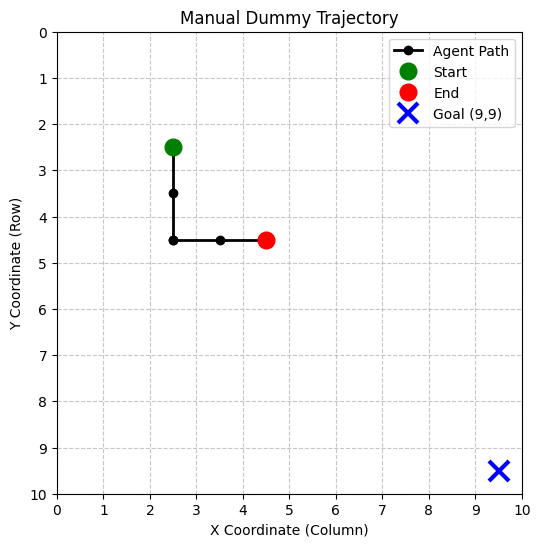

In [29]:


# ---------------------------------------------------------
# Let's test the environment!
# ---------------------------------------------------------
env = GridWorld(size=10)
obs, true_s = env.reset()

# Force the start location to (2, 2) just for this clear demonstration
env.agent_location = np.array([2, 2])
true_s = env.agent_location.copy()
obs = env._get_observation()

trajectory = [true_s.copy()]
action_names = {0: "Up", 1: "Down", 2: "Left", 3: "Right", 4: "Hint"}

print("--- ENVIRONMENT SIMULATION ---")
print(f"START    | True State: {true_s} | Noisy Obs: {obs.round(1)} | Noise Level: {env.noise_level}")

# We will move Down twice, take a Hint, then move Right twice
actions_to_take = [1, 1, 4, 3, 3] 

for a in actions_to_take:
    obs, true_s = env.step(a)
    trajectory.append(true_s.copy())
    
    # Notice how the Observation gets much closer to the True State after the 'Hint' action!
    action_str = action_names[a]
    print(f"Act: {action_str:<4} | True State: {true_s} | Noisy Obs: {obs.round(1)} | Noise Level: {env.noise_level}")

# Plot the path we just took
plot_trajectory(trajectory, grid_size=env.size, goal_location=env.goal_location, title='Manual Dummy Trajectory')

### The one-step back and forth free energy formulation:


The VFE functional can be used as a one-step backward retrospective quantifier and the EFE functional can be used as a one-step future prosprective account.

> **In the following, we will place ourselves at time $t$. I.e. we observe $o_t$ as the result of $s_t$ (which is unknown), and we infer $s_t$ both as the origin of $o_t$ (posdiction, or inference) and as the result of $a_{t-1}$ (prediction, $a_{t-1}$ is known). We assume also that, at time $t$, $s_{t-1}$ is KNOWN.**

For example:
- At $t=0$, we observe $o_0$ as the result of $s_0$ (which is unknown), and we infer $s_0$ as the origin of $o_0$ (inference). Then we take $a_{0}$ to go to time $t=1$.

- At $t=1$, we observe $o_1$ as the result of $s_1$ (which is unknown), and we infer $s_1$ both as the origin of $o_1$ and as the result of $a_{0}$. Then we take $a_{1}$ to go to time $t=2$.

- and so forth...

In other words, $h=0$, and the notation acquires this meaning:
$$
\boxed{
\begin{aligned}
\underline{o} &\triangleq o_{t:t}\equiv o_{t} \\
\underline{a} &\triangleq a_{t-1:t-1} \equiv a_{t-1}\\
\bar{a} &\triangleq  a_{t:t} \equiv a_t\\
\bar{s} &\triangleq  s_{t+1:t+1} \equiv s_{t+1}\\
\bar{o} &\triangleq  o_{t+1:t+1} \equiv o_{t+1}\\
\end{aligned}
}
$$

### The prior, posterior and likelihood nets:


**Having done our last action $a_{t-1}$, we want to evaluate our current generative model's complexity and accuracy w.r.t. the observation we got, $o_t$, and the state we are actually able to infer, $s_t$**:

The one-step-back retrospective VFE functional turns to be:
$$
\begin{aligned}
VFE & =  \underbrace{D_{KL} \left[\overbrace{q_{o_{t}}(s_t\mid a_{t-1})}^{\text{approx. posterior}} || \overbrace{Q(s_t \mid a_{t-1})}^{\text{Prior}} \right]}_{\text{Complexity}} - \overbrace{\underbrace{\mathbb{E}_{q_{o_{t}}(s_t\mid a_{t-1})}\left[ \ln \overbrace{Q(o_{t} \mid s_t)}^{\text{likelihood model}} \right]}_{\text{Accuracy}}}^{\text{how likely  } o_t  \text{  is under appox. post.}} \\
\end{aligned}
$$

Our variational posterior, instead, will be implemented using a neural network $\mathbf{q}_{\theta}(o_{t}, a_{t-1})$, parametrised by $\theta$, such that it's output will be also the inferred state $\hat{s}_{t}$:

$$
\boxed{
\begin{aligned}
\text{Variational Posterior Net:}\\
\hat{s}_{t} \leftarrow \mathbf{q}_{\theta}(o_{t}, a_{t-1})\\
\text{learn} \quad \theta^* \quad \text{such that}\quad \hat{s}_{t} \sim q_{o_{t}}(s_{t}\mid a_{t-1})\\
\end{aligned}
}
$$

The first line in this box indicates that $\hat{s}_{t}$ is a guess or inference about the real underlying state of the world, $s_{t}$, which is obtained as the output of neural networks, when these are fed with some inputs.

Now the second line is interesting because it is saying that we want to learn some optimal values of the net parameters $\theta^*$ such that we can assume that its outputs are equivalent to _sampling_ from the distribution it approximates!

### A Note on the Gaussian Assumption

Before we move on to how we train these networks, we need to bridge a gap between the probabilistic math we've derived and the neural networks we are about to code. 

How do we compute the KL divergence between abstract probability distributions when our neural networks just output deterministic vectors (like $\hat{s}_t$)?

The standard trick in Variational Autoencoders (VAEs) and Deep Active Inference is to **assume our distributions are spherical (isotropic) Gaussians** with a fixed variance (usually an identity covariance matrix $I$). Under this assumption, our neural networks don't need to output a full probability distribution; they just output the **mean** ($\mu$) of the Gaussian.

Thanks to this assumption, the KL divergence between two such Gaussians mathematically simplifies to a scaled Euclidean distance ($L_2$ norm) between their means:

$$
D_{KL}[\mathcal{N}(\mu_1, I) \parallel \mathcal{N}(\mu_2, I)] = \frac{1}{2} \|\mu_1 - \mu_2\|_2^2
$$

This elegant property is what allows us to translate our abstract Free Energy functionals into simple, codeable Mean Squared Error (MSE) loss functions!

In [4]:
# Let's define our Posterior Network (\mathbf{q}_\theta)
# It takes the current observation (o_t) and previous action (a_{t-1}) 
# and infers the mean of the hidden state (\hat{s}_t)

class PosteriorNet(nn.Module):
    def __init__(self, obs_dim=2, action_dim=5, state_dim=2, hidden_dim=64):
        super().__init__()
        # We concatenate observation and action as input
        self.fc1 = nn.Linear(obs_dim + action_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mean = nn.Linear(hidden_dim, state_dim) # Outputs \hat{s}_t
        
    def forward(self, obs, action_one_hot):
        # Concatenate along the feature dimension
        x = torch.cat([obs, action_one_hot], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc_mean(x)
    

posterior_net = PosteriorNet().to(device)

print(r"Posterior Network initialized! This is our variational posterior $\mathbf{q}_\theta(o_t, a_{t-1})$.")

Posterior Network initialized! This is our variational posterior $\mathbf{q}_\theta(o_t, a_{t-1})$.


### Testing the Posterior Network (State Inference)

In our `GridWorld`, the agent never sees its true `(x, y)` coordinates. It only gets a noisy GPS reading (the observation $o_t$). 

To figure out where it actually is, the agent acts like a detective using its **Posterior Network** $\mathbf{q}_\theta(o_t, a_{t-1})$. This network pieces together two clues:
1. **What it just saw** (the noisy observation $o_t$).
2. **What it just did** (the previous action $a_{t-1}$. If the agent knows it just moved "Right", that is a huge clue about its current location!).

Let's grab a real observation from our environment, pretend we just took an action, and pass them into the network. 

*Deep Learning Note:* Neural networks cannot easily digest categorical numbers (like `3` for "Right"). If we just feed it a `3`, the network might think "Right" is three times bigger than "Down" (`1`). To fix this, we convert the discrete action into a **one-hot encoded vector** (e.g., Action 3 becomes `[0, 0, 0, 1, 0]`).

In [34]:
# 1. Let's set up a specific scenario in our GridWorld
env = GridWorld(size=10)
env.agent_location = np.array([5, 5])  # Force true state to be exactly at (5, 5)
obs = env._get_observation()           # Get the noisy GPS reading (o_t)

# 2. Pretend our last action was "Right" (Action index 3)
last_action = 3                        # (a_{t-1})

# 3. Format the inputs for PyTorch
# Neural networks expect data in "batches", so we add an extra dimension using .unsqueeze(0)
# Shape goes from [2] to [1, 2]
obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device) 

# Convert the integer action into a one-hot vector
action_tensor = torch.tensor([last_action])
action_one_hot = F.one_hot(action_tensor, num_classes=env.action_space_size).float().to(device)

# 4. Ask the Posterior Network to guess our true state!
with torch.no_grad(): # We use no_grad() because we are just guessing, not training
    guessed_state = posterior_net(obs_tensor, action_one_hot)
    
print("--- PERCEPTION TEST ---")
print(f"True State (Hidden from agent): {env.agent_location}")
print(r"Noisy Observation $o_t$:        {obs.round(2)}")
print(r"Last Action $a_t-1$:            {last_action} (One-Hot: {action_one_hot.cpu().numpy()[0]})")
print(r"Network's Guess $\hat{{s}}_t$:       {guessed_state.cpu().numpy()[0].round(2)}")
print("-" * 23)
print("Notice how the network's guess is probably terrible right now?")
print("That's because the weights are completely random! We haven't trained it yet.")
print("To fix this, we will minimize the Variational Free Energy (VFE).")

--- PERCEPTION TEST ---
True State (Hidden from agent): [5 5]
Noisy Observation $o_t$:        {obs.round(2)}
Last Action $a_t-1$:            {last_action} (One-Hot: {action_one_hot.cpu().numpy()[0]})
Network's Guess $\hat{{s}}_t$:       {guessed_state.cpu().numpy()[0].round(2)}
-----------------------
Notice how the network's guess is probably terrible right now?
That's because the weights are completely random! We haven't trained it yet.
To fix this, we will minimize the Variational Free Energy (VFE).


In [37]:
# Let's see another example of the posterior network in action

# 1. Pretend we just took a step in our GridWorld
last_action = 3  # We moved Right
env.agent_location = np.array([5, 5]) # The True State (which the agent CANNOT see)
true_state = env.agent_location.copy()

# The agent receives a noisy observation
noisy_obs = env._get_observation()

# 2. Prepare the data for PyTorch
# We must convert our numpy arrays into PyTorch Tensors and add a "batch" dimension
obs_tensor = torch.FloatTensor(noisy_obs).unsqueeze(0).to(device)  # Shape: [1, 2]

# Create the tensor for the action and apply One-Hot Encoding
action_tensor = torch.tensor([last_action]).to(device)
action_one_hot = F.one_hot(action_tensor, num_classes=env.action_space_size).float() # Shape: [1, 5]

print("--- INPUTS TO THE NETWORK ---")
print(f"Noisy Observation (o_t): {obs_tensor.cpu().numpy()}")
print(f"Last Action One-Hot (a_t-1): {action_one_hot.cpu().numpy()}")

# 3. Ask the network to guess the true state
# We use torch.no_grad() because we are just guessing right now, not training!
with torch.no_grad():
    inferred_state = posterior_net(obs_tensor, action_one_hot)

print("\n--- THE RESULTS ---")
print(f"True State (Hidden):      {true_state}")
print(r"Network's Guess $\hat{{s}}_t$: {inferred_state.cpu().numpy().round(2)}")

print("\nNotice how bad the network's guess is right now! It might guess negative coordinates or huge numbers.")
print("This is because the network weights are completely random. We need to train it using the VFE Complexity loss!")

--- INPUTS TO THE NETWORK ---
Noisy Observation (o_t): [[6.564644 2.380255]]
Last Action One-Hot (a_t-1): [[0. 0. 0. 1. 0.]]

--- THE RESULTS ---
True State (Hidden):      [5 5]
Network's Guess $\hat{{s}}_t$: {inferred_state.cpu().numpy().round(2)}

Notice how bad the network's guess is right now! It might guess negative coordinates or huge numbers.
This is because the network weights are completely random. We need to train it using the VFE Complexity loss!


### The retrospective step:

Suppose for a second we are at time $t-2$, suppose we perform an action $a_{t-2}$, then we go to time $t-1$. At that moment the state $s_{t-2}$ *unhides*, it becomes visible, that is our assumption. 

> **Then suppose we perform an action $a_{t-1}$, then we go to time $t$ and the state $s_{t-1}$ unhides.**
> 
> This means that, at (any) time $t$, we could use $o_{t-1}$ and $a_{t-2}$ to make a guess about $s_{t-1}$, say $\hat{s}_{t-1}$, from the approx. posterior. Knowing that we now have the real $s_{t-1}$, we can use it as the empirical mean of our prior $Q(s_{t-1} \mid a_{t-2})$. 
>
> By applying the Gaussian assumption we just discussed, we can compute the complexity term of the VFE as the scaled $L_2$ distance between the output of our posterior net ($\hat{s}_{t-1}$) and the unhidden true state ($s_{t-1}$):
> $$
  \begin{aligned}
  \hat{s}_{t-1} &\leftarrow \mathbf{q}_{\theta}(o_{t-1}, a_{t-2}) \quad &\text{(mean of approx. posterior } q)\\
  {s}_{t-1} &\leftarrow \text{unhidden true state} \quad &\text{(mean of prior } Q)\\
  &\implies\\
  \underbrace{D_{KL} \left[{q_{o_{t-1}}(s_{t-1}\mid a_{t-2})} \parallel {Q(s_{t-1} \mid a_{t-2})} \right]}_{\text{VFE Complexity term}} &\approx \frac{1}{2} ||\hat{s}_{t-1} - s_{t-1} ||^2_2 \\
  \end{aligned}
  $$

Yes, I know, we cannot do that for every $t$ but only from $t=2$ (or $t=1$ if we create a phantom $a_{-1}$). But don't worry, from $t=2$ onwards, there's a lot of time for learning :)

### Fixing the Guesses: Minimizing VFE via Gradient Descent

The summary of what we have just said is: How do we make our network smarter? We wait for the environment to "unhide" the true state, and then we look back in time. 

If the network guessed `[0.5, 2.1]` but the true state was `[1.0, 0.0]`, we calculate the difference. As we learned in the math section, under the Gaussian assumption, the **VFE Complexity** reduces to half the Mean Squared Error (MSE) between the guess and the true state.

In PyTorch, we minimize this error using an **Optimizer** (like Adam). The optimizer calculates the gradients (using backpropagation) and nudges the network's weights so that its next guess will be closer to the truth. 

Let's run a mini training loop for just 10 steps to see the network learn!

We are now going to let the agent take **10000 random actions** (wandering aimlessly around the grid). 

At each step, the agent will:
1. Look at its noisy GPS (`obs_t`) and remember its last move (`last_action`).
2. Make a guess about its true location (`guessed_state`).
3. Have the environment "unhide" the true location (`true_s_t`).
4. Calculate the **VFE Complexity** (the error between the guess and the truth).
5. Use **Backpropagation** to update its brain.

Because the sensors are noisy, the loss will bounce around a bit, but over time, we should see a clear downward trend as the network figures out how to filter out the noise!

Starting Random Exploration Training for the Posterior Net...

Step 200  | Target: [2 7] | Guess: [2.1 7.5] | Loss: 0.2647
Step 400  | Target: [0 7] | Guess: [0.  6.8] | Loss: 0.0077
Step 600  | Target: [4 3] | Guess: [4.  2.2] | Loss: 0.0077
Step 800  | Target: [0 7] | Guess: [1.1 7.4] | Loss: 0.0330
Step 1000 | Target: [1 7] | Guess: [1.2 6.7] | Loss: 0.0235
Step 1200 | Target: [6 0] | Guess: [ 5.2 -0.1] | Loss: 0.0101
Step 1400 | Target: [5 2] | Guess: [4.9 3.4] | Loss: 0.0364
Step 1600 | Target: [3 1] | Guess: [2.9 0.1] | Loss: 0.0040
Step 1800 | Target: [8 4] | Guess: [9. 4.] | Loss: 0.0005
Step 2000 | Target: [7 1] | Guess: [7.8 1. ] | Loss: 0.0079
Step 2200 | Target: [6 3] | Guess: [5.6 1.7] | Loss: 0.0506
Step 2400 | Target: [0 6] | Guess: [-0.1  4.9] | Loss: 0.0052
Step 2600 | Target: [0 8] | Guess: [1.1 8.1] | Loss: 0.0084
Step 2800 | Target: [6 8] | Guess: [5.9 7.6] | Loss: 0.0499
Step 3000 | Target: [1 3] | Guess: [2.  3.3] | Loss: 0.0177
Step 3200 | Target: [7 0] | Guess: 

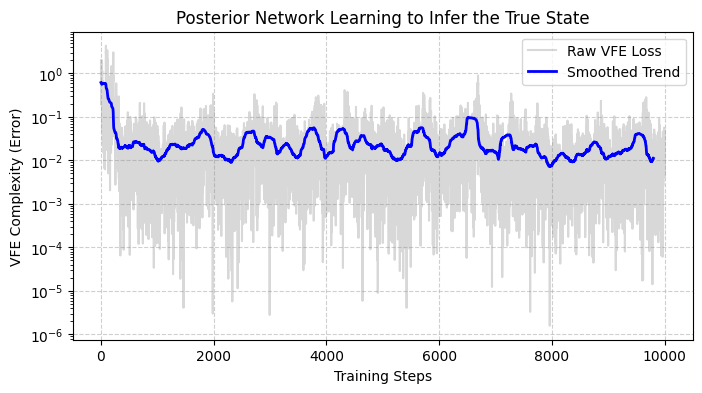


Training Complete! The downward trend proves the network learned to filter out the sensor noise.


In [54]:
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Re-initialize to ensure we start with a fresh, untrained brain!
posterior_net = PosteriorNet(obs_dim=2, action_dim=5, state_dim=2).to(device)
posterior_optimizer = optim.Adam(posterior_net.parameters(), lr=0.002)

# 2. Reset the environment
env = GridWorld(size=10)
obs, true_s = env.reset()
last_action = 0 # Arbitrary initial action

# We will store the losses here to plot them later
vfe_losses =[]

print("Starting Random Exploration Training for the Posterior Net...\n")

# 3. The Training Loop (1,000 steps of random wandering)
for step in range(1, 10001):
    
    # --- A. Format Data for PyTorch ---
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
    true_s_tensor = torch.FloatTensor(true_s).unsqueeze(0).to(device)
    
    # One-hot encode the last action
    action_tensor = torch.tensor([last_action])
    action_one_hot = F.one_hot(action_tensor, num_classes=env.action_space_size).float().to(device)
    
    # --- B. Forward Pass (Guess the state) ---
    guessed_state = posterior_net(obs_tensor, action_one_hot)
    
    # --- C. Compute VFE Complexity (MSE scaled by 0.5) ---
    vfe_complexity = 0.5 * F.mse_loss(guessed_state, true_s_tensor)
    
    # --- D. Backpropagation (Update the weights) ---
    posterior_optimizer.zero_grad()
    vfe_complexity.backward()
    posterior_optimizer.step()
    
    # Save the loss for plotting
    vfe_losses.append(vfe_complexity.item())
    
    # --- E. Interact with the Environment ---
    # Take a completely RANDOM action to explore the grid
    action = np.random.choice(env.action_space_size)
    next_obs, next_true_s = env.step(action)
    
    # Update our variables for the next loop iteration
    obs = next_obs
    true_s = next_true_s
    last_action = action
    
    # Print progress every 200 steps
    if step % 200 == 0:
        guess_print = guessed_state.detach().cpu().numpy()[0].round(1)
        print(f"Step {step:<4} | Target: {true_s} | Guess: {guess_print} | Loss: {vfe_complexity.item():.4f}")

# 4. Plot the Convergence!
# Because the environment is naturally noisy, the loss jumps around.
# We will calculate a "Moving Average" to make the learning curve easier to see.
def moving_average(data, window_size=200):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_losses = moving_average(vfe_losses)

plt.figure(figsize=(8, 4))
plt.plot(vfe_losses, alpha=0.3, color='gray', label='Raw VFE Loss')
plt.plot(smoothed_losses, color='blue', linewidth=2, label='Smoothed Trend')
plt.title("Posterior Network Learning to Infer the True State")
plt.xlabel("Training Steps")
plt.ylabel("VFE Complexity (Error)")
plt.legend()
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nTraining Complete! The downward trend proves the network learned to filter out the sensor noise.")

> *"Now in this tutorial, we could have included a likelihood model $Q(o_t | s_t)$ and optimized it using the Accuracy term of the VFE (essentially acting as a Decoder). But we won't.* 
>
> *Why? In deep learning, forcing an agent to reconstruct high-dimensional observations (like raw pixels) often causes the latent space to waste capacity modeling irrelevant background noise—the classic 'distractor problem'. By bypassing the generative likelihood and focusing only on the VFE Complexity term and the EFE, we force our latent representations to be strictly task-centric and dynamics-centric. We are doing Active Inference via latent forward-prediction rather than sensory reconstruction."*

Now the only problem is,we have so far talked about taking actions at time $t-2$,$t-1$, and, in general, at time $t$. Now the question is: what action $a_t$ to make each time?? We'll answer that question, and apply the active inference paradigm, in the next section.

### The Policy model:

**So now we focus on the prospective step, which is about taking our next action $a_t$.**

We will use a neural network called the policy net that is going to tell us each time what action to take :) This network is supposed to help us pick the best action—namely, the one that minimises the Expected Free Energy (EFE) functional.


Instead of directly outputting a hardcoded action, the policy network $\mathbf{Q}_{\phi}(s_t)$, parameterized by $\phi$, will output a **probability distribution** over all possible actions given the current (inferred) state $s_t$. Let's call this predicted distribution $\pi_t$. We then *sample* our next action $a_t$ from it. 

This is our policy model, our way of acting:

$$
\boxed{
\begin{aligned}
&\text{Policy Net:}\\
\pi_t &= \mathbf{Q}_{\phi}(s_t) \quad &&\text{(Outputs action probabilities)}\\
a_t &\sim \pi_t \quad &&\text{(Sample the action to take)}\\
&\text{learn} \quad \phi^* \quad \text{such that} \quad &&\pi_t \approx \sigma[-\zeta \mathbf{G}_{\psi}(s_t, \mathbf{a})]
\end{aligned}
}\tag{PN}
$$


Wait. What in the world is $\sigma[-\zeta \mathbf{G}_{\psi}(s_t, \mathbf{a})]$?

This is what we call a **Gibbs distribution**. Let's break it down:

- $\sigma[\cdot]$ is the **Softmax operator**. It basically transforms a *set* of arbitrary numerical inputs into a valid probability distribution (all values sum to 1, forming a simplex).

- $\zeta$ (zeta) is a **precision hyperparameter**. It is a scalar that shapes the actual polarization or entropy of the resultant probability distribution. A very high $\zeta$ makes the agent highly deterministic and greedy (exploiting the best EFE), while a low $\zeta$ softens the distribution, making the agent more random and exploratory.



- The $\mathbf{G}_{\psi}(s_t, \mathbf{a})$ guy denotes a vector of the approximate EFE values for each possible action $a \in \mathbf{a}$. And yes, you might have guessed right: that vector is the output of *another* neural network!

- The **minus sign** is crucial! Remember that EFE is a *cost* or an *energy* that we want to **minimise**. By negating it before applying the Softmax, we ensure that the actions with the *lowest* Expected Free Energy get the *highest* probability of being chosen. 

In [49]:
# Now let's define the "Prospective" brains: The Policy and Critic Networks

class PolicyNet(nn.Module):
    def __init__(self, state_dim=2, num_actions=5, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        # Outputs logits (raw scores) for each possible action
        self.fc_logits = nn.Linear(hidden_dim, num_actions)
        
    def forward(self, state):
        x = F.relu(self.fc1(state))
        logits = self.fc_logits(x)
        return logits # We return logits; we will apply Softmax (Gibbs) later


In [50]:
# =============================================================================
# PROXY EFE FOR PEDAGOGICAL POLICY TRAINING
# =============================================================================
# Before we introduce the learned Critic (which will estimate the real EFE),
# we create a **hand-crafted proxy** that already captures the two core drives:
#   1. Pragmatic: "get closer to the goal (9,9)"
#   2. Epistemic:  "use the Hint action to reduce sensor noise"
#
# This proxy lets us train the Policy Net *independently* so we can see
# how the Gibbs distribution (softmax[-ζ·EFE]) naturally produces goal-directed
# + curious behaviour without any temporal-difference learning yet.
#
# (We will replace this proxy with the learned Critic in the next cell.)

def compute_proxy_efe(inferred_state, goal_location):
    """
    Returns a vector of proxy EFE values for each action (0-4).
    Lower = better (we will minimise EFE).
    
    Pragmatic component: expected distance to goal after the move
    Epistemic component: strong bonus (negative cost) for the Hint action
    """
    inferred = np.array(inferred_state)
    goal = np.array(goal_location)
    
    # Deterministic move deltas (same as the environment)
    deltas = np.array([
        [-1.,  0.],  # 0 = Up
        [ 1.,  0.],  # 1 = Down
        [ 0., -1.],  # 2 = Left
        [ 0.,  1.],  # 3 = Right
        [ 0.,  0.]   # 4 = Hint (no movement)
    ])
    
    proxy_efe = np.zeros(5)
    
    for a in range(5):
        # Simulate what the *next* inferred state would be (deterministic move)
        next_est = np.clip(inferred + deltas[a], 0, 9)
        
        # === Pragmatic component (goal-seeking) ===
        # Positive penalty = higher when we are far from (9,9)
        pragmatic = 0.5 * np.sum((next_est - goal)**2)
        
        # === Epistemic component (curiosity / information gain) ===
        # Hint gives a strong negative cost (we WANT to take it sometimes)
        # Moves have zero epistemic bonus in this simple proxy
        epistemic = -5.0 if a == 4 else 0.0
        
        proxy_efe[a] = pragmatic + epistemic
    
    return proxy_efe

Training Policy Net with Proxy EFE (pragmatic + epistemic)...

Step 200   | Proxy EFE: [58.18 47.83 53.9  44.16 47.51] | Best action: 3 | Policy loss: 0.0000
Step 400   | Proxy EFE: [57.3  48.42 63.17 51.58 51.88] | Best action: 1 | Policy loss: 0.0000
Step 600   | Proxy EFE: [31.39 19.62 29.43 21.58 20.  ] | Best action: 1 | Policy loss: 0.2915
Step 800   | Proxy EFE: [44.32 28.46 39.38 33.4  30.89] | Best action: 1 | Policy loss: 0.0000
Step 1000  | Proxy EFE: [39.48 25.66 36.61 28.52 27.07] | Best action: 1 | Policy loss: 0.0013
Step 1200  | Proxy EFE: [38.06 23.7  33.92 27.84 25.38] | Best action: 1 | Policy loss: 0.3726
Step 1400  | Proxy EFE: [52.42 43.96 49.44 39.39 42.69] | Best action: 3 | Policy loss: 0.0000
Step 1600  | Proxy EFE: [42.26 32.22 44.19 30.29 31.74] | Best action: 3 | Policy loss: 0.0012
Step 1800  | Proxy EFE: [40.51 30.44 39.36 38.74 33.74] | Best action: 1 | Policy loss: 0.0000
Step 2000  | Proxy EFE: [71.41 55.48 71.35 55.54 57.95] | Best action: 1 | Policy 

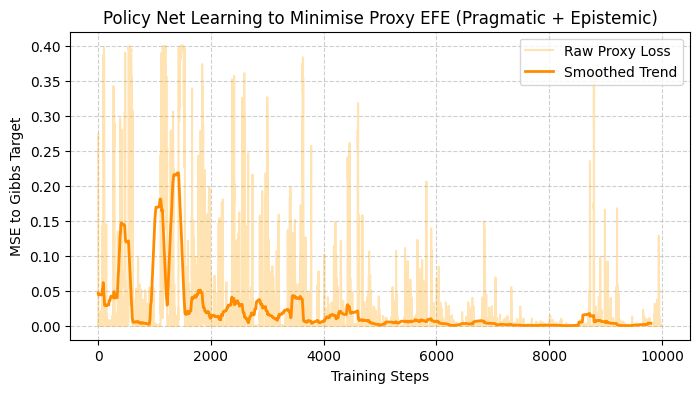


Policy Net is now trained on the proxy! It already prefers moves toward (9,9) and occasionally takes the Hint action (epistemic drive).
In the next cell we will replace this proxy with the learned Critic Net.


In [56]:
# =============================================================================
# INDEPENDENT POLICY TRAINING WITH PROXY EFE
# =============================================================================
# We now let the agent wander randomly while the Policy Net is supervised
# to match the Gibbs distribution of the proxy EFE.
# This is exactly the same logic that will later be used with the learned Critic.

zeta_proxy = 2.0
policy_net = PolicyNet(state_dim=2, num_actions=5).to(device)
policy_optimizer = optim.Adam(policy_net.parameters(), lr=0.01)

# Reset environment
env = GridWorld(size=10)
obs, true_s = env.reset()
last_action = 0

proxy_losses = []
print("Training Policy Net with Proxy EFE (pragmatic + epistemic)...\n")

for step in range(1, 10001):
    
    # 1. Infer current state with the already-trained Posterior Net
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
    action_oh = F.one_hot(torch.tensor([last_action]), num_classes=5).float().to(device)
    with torch.no_grad():
        inferred_state = posterior_net(obs_tensor, action_oh).cpu().numpy()[0]
    
    # 2. Compute proxy EFE vector (the "teacher signal")
    proxy_efe_vec = compute_proxy_efe(inferred_state, env.goal_location)
    proxy_efe_tensor = torch.FloatTensor(proxy_efe_vec).unsqueeze(0).to(device)
    
    # 3. Target probabilities = Gibbs distribution of the proxy
    target_probs = F.softmax(-zeta_proxy * proxy_efe_tensor, dim=-1)
    
    # 4. Current policy probabilities
    state_tensor = torch.FloatTensor(inferred_state).unsqueeze(0).to(device)
    logits = policy_net(state_tensor)
    current_probs = F.softmax(logits, dim=-1)
    
    # 5. Loss = make the policy match the proxy Gibbs distribution
    policy_loss = F.mse_loss(current_probs, target_probs)
    
    policy_optimizer.zero_grad()
    policy_loss.backward()
    policy_optimizer.step()
    
    proxy_losses.append(policy_loss.item())
    
    # 6. Take a random action (pure exploration of the state space)
    action = np.random.choice(env.action_space_size)
    obs, true_s = env.step(action)
    last_action = action
    
    if step % 200 == 0:
        best_action = np.argmin(proxy_efe_vec)
        print(f"Step {step:<5} | "
              f"Proxy EFE: {proxy_efe_vec.round(2)} | "
              f"Best action: {best_action} | "
              f"Policy loss: {policy_loss.item():.4f}")

# =============================================================================
# Plot convergence
# =============================================================================
smoothed_proxy = moving_average(proxy_losses, window_size=200)

plt.figure(figsize=(8, 4))
plt.plot(proxy_losses, alpha=0.3, color='orange', label='Raw Proxy Loss')
plt.plot(smoothed_proxy, color='darkorange', linewidth=2, label='Smoothed Trend')
plt.title("Policy Net Learning to Minimise Proxy EFE (Pragmatic + Epistemic)")
plt.xlabel("Training Steps")
plt.ylabel("MSE to Gibbs Target")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nPolicy Net is now trained on the proxy! It already prefers moves toward (9,9) "
      "and occasionally takes the Hint action (epistemic drive).")
print("In the next cell we will replace this proxy with the learned Critic Net.")

### The critic network:

The "value" of an action is a well-established concept in RL by which we rate the next action to take. Usually people talk about rating "policies" rather than actions. In RL jargon, policies are functions that output actions given states, in Act.Inf jargon, policies are just sequences of actions. Anyway, we are going to choose the NEXT action, $a_{t}$, i.e., our planning horizon will be just $h=1$, and guess what the rating score will be? Yep, you guessed, the EFE.


We will create a neural network that approximates the EFE for each action $a \in \mathbf{a}$. Following the RL naming conventions, we'll call this fella the _critic network_ $\mathbf{G}_{\psi}(\mathbf{a},s_{t})$, as it will estimate the EFE associated with each potentially next action $a_{t}$ given the current (inferred) state, $s_{t}$. The parameters of this neural network are denoted by $\psi$.  

In [55]:
class CriticNet(nn.Module):
    def __init__(self, state_dim=2, num_actions=5, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc_efe = nn.Linear(hidden_dim, num_actions)
        
    def forward(self, state):
        x = F.relu(self.fc1(state))
        return self.fc_efe(x)
    

critic_net = CriticNet().to(device)
print("Policy Network (Q_phi) and Critic Network (G_psi) initialized!")

Policy Network (Q_phi) and Critic Network (G_psi) initialized!


So we create this neural net, we initialise it with whatever values. We will then optimise such values using our favorite learning paradigm (for now, lets suppose stochastic gradient descent). Above of that learning dynamics, the macro-structural way of optimising the $\mathbf{G}$ guy will be through what is called "temporal difference learning", i.e., we will use some *real* one-step feedback from the world, add our current $\mathbf{G}$-based estimate of the rest of future steps, and use this thing as if it were "the truth", then optimise our $\mathbf{G}$ to fit that "truth". (This is what bootstrapping means, like lifting ourselves from the ground by pulling our bootstraps up). Anyways, it turns out to work:

$$
\boxed{
\begin{aligned}
&\quad \quad \text{The Critic Network}\\
\underbrace{\mathcal{G}(a_{t}, s_{t})}_{\text{This is ground truth EFE}} \triangleq & \underbrace{\bar{\mathcal{G}}(a_{t}, s_{t})}_{\text{Real feedback}}  + \underbrace{\gamma}_{\text{``discount factor"}} \cdot \min \underbrace{ \left[  \hat{\mathbf{G}}_{\hat{\psi}}(\mathbf{a}, s_{t+1}) \right]  }_{\text{Critic's net EFE estimate }}\\\\
\text{learn}  &\quad \psi^* \quad \text{such that:} \quad {\mathbf{G}}_{{\psi}^*}(a_{t}, s_{t}) \to \mathcal{G}(a_{t}, s_{t})
\end{aligned}
}
$$

But wait, what is this $\bar{\mathcal{G}}(a_{t}, s_{t})$ guy? It is precisely a one-step a-posteriori computed value of the EFE. We take an action at time $t$, see what happens... and ask ourselves, what was the free energy of that single action?

Recall the one-step EFE formulation:
$$
\begin{aligned}
EFE \triangleq - \underbrace{\mathbb{E}_{Q( o_{t+1} | a_t)}\left[D_{KL}\left[Q(s_{t+1} | o_{t+1} , a_t) ||q_{o_{t+1}}(s_{t+1}\mid a_t) \right]\right]}_{\text{One-step epistemic gain}} - \underbrace{\mathbb{E}_{Q( o_{t+1}| a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]}_{\text{One-step pragmatic Gain}}\\\\
\end{aligned}
$$

We use that structure to compute our $\bar{\mathcal{G}}(a_{t}, s_{t})$ fella:
$$
\begin{aligned}
\\
&\underbrace{\bar{\mathcal{G}}(a_{t}, s_{t})}_{\text{one-step feedback}}\triangleq \\
& \quad \quad - \underbrace{\mathbb{E}_{Q( o_{t+1} | a_t)}\left[D_{KL}\left[Q(s_{t+1} | o_{t+1} , a_t) ||q_{o_{t+1}}(s_{t+1}\mid a_t) \right]\right]}_{\text{one-step epistemic gain}} \\
& \quad \quad - \underbrace{\mathbb{E}_{Q( o_{t+1}| a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]}_{\text{one-step pragmatic Gain}}\\
\end{aligned}
$$



#### The one-step epistemic gain:

It is not the case that we will implement the epistemic gain at time $t$, because we do not know the real posterior $Q(s_{t+1} \mid o_{t+1} , a_t)$. We actually do not even know the real posterior at time $t$, $Q(s_{t} \mid o_{t} , a_{t-1})$.

However, at time $t$, $s_{t-1}$ is known and can be used as a point estimation of the real posterior, just as we did for the VFE.

**Before, for the VFE Complexity, we did:**
$$
\begin{aligned}
\hat{s}_{t-1} &\leftarrow \mathbf{q}_{\theta}(o_{t-1}, a_{t-2}) \quad &\text{(mean of approx. posterior } q)\\
{s}_{t-1} &\leftarrow \text{unhidden true state} \quad &\text{(mean of prior } Q)\\
&\implies\\
\underbrace{D_{KL} \left[{q_{o_{t-1}}(s_{t-1}\mid a_{t-2})} \parallel {Q(s_{t-1} \mid a_{t-2})} \right]}_{\text{VFE Complexity term}} &\approx \frac{1}{2} ||\hat{s}_{t-1} - s_{t-1} ||^2_2 \\
\end{aligned}
$$


**Now, for the Epistemic Gain, we do:**
Applying the same Gaussian assumption, the KL divergence inside the expectation translates to a scaled $L_2$ distance:
$$
\underbrace{\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[D_{KL}\left[Q(s_{t-1} \mid o_{t-1} , a_{t-2}) \parallel q_{o_{t-1}}(s_{t-1}\mid a_{t-2}) \right]\right]}_{\text{one-step epistemic gain}} \approx \mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2\right]
$$

Notice the difference in the arguments of the KL divergence! In the VFE complexity, it was $q \parallel Q$, but here in the epistemic gain, it is reversed: $Q \parallel q$. Furthermore, the true distribution here is the posterior $Q(s \mid o,a)$, not the prior $Q(s \mid a)$. 


However, because the Euclidean distance is symmetric ($\|A - B\|_2^2 = \|B - A\|_2^2$), the Gaussian assumption gifts us a beautiful mathematical convenience: the reversed divergence boils down to the exact same Mean Squared Error format!

Now, since we actually *saw* the observation $o_{t-1}$, we can approximate the outer expectation using this single sample (Monte Carlo approximation). We simply evaluate the inner term without the expectation operator:

$$\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2\right] \approx \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2$$

Summarising:

$$
\boxed{
  \begin{aligned}
  &\text{Approximated one-step epistemic gain (from } t-1 \text{ to } t \text{):}\\
  &\hat{s}_{t-1} =  \mathbf{q}_{\theta}(o_{t-1}, a_{t-2})\\
&\underbrace{\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[D_{KL}\left[Q(s_{t-1} \mid o_{t-1} , a_{t-2}) \parallel q_{o_{t-1}}(s_{t-1}\mid a_{t-2}) \right]\right]}_{\text{one-step epistemic gain}}\approx \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1}\right\|_2^2
\end{aligned}
}
$$

#### The one-step pragmatic gain:

This is our pragmatic term: the expectation of the log-likelihood of future observations under our vital/goal distribution $\mathbf{C}$:

$$
\mathbb{E}_{Q( o_{t+1} \mid a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]
$$

To train our critic network using real feedback, we evaluate this expectation retrospectively, looking at the transition from $t-1$ to $t$. The expectation becomes:

$$
\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \ln Q(o_{t-1} \mid \mathbf{C}) \right]
$$


Since we actually executed the action and observed $o_{t-1}$, we can again use a single-sample Monte Carlo approximation to drop the expectation operator:

$$\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \ln Q(o_{t-1} \mid \mathbf{C}) \right]
 \approx  \ln Q(o_{t-1} \mid \mathbf{C})
$$

Now, how do we compute this normative log-probability? We impose it as a desideratum. Suppose we have a specific desired target observation $o^*$. If we apply our trusty Gaussian assumption, we model the vital distribution $Q(o \mid \mathbf{C})$ as a Gaussian centered at $o^*$.

**Crucially, the log-probability of a Gaussian is proportional to the *negative* squared distance!** 

$$
\ln Q(o_{t-1} \mid \mathbf{C}) \approx -\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2
$$

*(Note the minus sign! This makes intuitive sense: as your observation gets further from your goal $o^*$, its log-probability becomes more negative.)*


$$
\boxed{
  \begin{aligned}
  &\text{Approximated one-step pragmatic gain:}\\
&\ln Q(o_{t-1} \mid \mathbf{C}) \approx -\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2
\end{aligned}
}
$$


#### Putting it together: The one-step EFE feedback

Let's assemble the ground-truth 1-step Expected Free Energy $\bar{\mathcal{G}}$. Recall the overarching formula:
$$ EFE \triangleq - \text{Epistemic Gain} - \text{Pragmatic Gain} $$


Let's shift our indices generically to the transition from $t$ to $t+1$ (evaluating action $a_t$) and substitute our Gaussian approximations:
- **Epistemic Gain**: $\approx \frac{1}{2} \left\| s_{t+1} - \hat{s}_{t+1} \right\|_2^2$
- **Pragmatic Gain**: $\approx -\frac{1}{2} \left\| o_{t+1} - o^* \right\|_2^2$



$$
\boxed{
\begin{aligned}
&\text{Approximated one-step EFE feedback for action } a_t:\\
&\bar{\mathcal{G}}(a_t, s_t) \approx - \underbrace{\frac{1}{2} \left\| s_{t+1} - \hat{s}_{t+1} \right\|_2^2}_{\text{Curiosity (minimise EFE to explore)}} + \underbrace{\frac{1}{2} \left\| o_{t+1} - o^* \right\|_2^2}_{\text{Goal-seeking (minimise EFE to exploit)}}
\end{aligned}
}
$$
Notice what happens with the minus signs: the double negative on the pragmatic gain turns it into a *positive* distance penalty! 

Because our agent wants to **minimise** the EFE, this final equation perfectly balances two drives: it wants to make the epistemic error *large* (driving exploration/curiosity) while making the distance to the goal *small* (driving exploitation/pragmatism).

### Training the Critic: Learning to Predict the Future

Now let's drop our `CriticNet` into the environment. Its job is to predict the **Expected Free Energy (EFE)** of every action before we actually take it. 

To train it, we will again let use the pre-trained policy net to choose actions for 2000 steps. At each step, we calculate the "Ground Truth" EFE based on what actually happened:
1. **Epistemic Gain:** Did our `PosteriorNet` guess the new state correctly, or was it surprised by the sensor noise? (Curiosity)
2. **Pragmatic Penalty:** How far is the new observation from the `Goal Location (9, 9)`? (Exploitation)
3. **Bootstrapping (TD Learning):** We add the 1-step EFE to the *future* EFE estimated by our `Target Critic`.

*Deep Learning Note:* In Temporal Difference (TD) learning, the "Truth" we are trying to fit keeps changing as the network gets smarter. To prevent the network from chasing its own tail, we use a frozen **Target Network** to estimate the future, and we only update this target network every 200 steps. You will actually see this in the loss plot as regular "spikes"!

Starting Random Exploration Training for the Critic Net...

Step 100  | 1-Step EFE: 2.08 | Predicted EFE: -1.23 | Target EFE: -1.30 | Loss: 0.01
Step 200  | 1-Step EFE: 2.12 | Predicted EFE: -1.21 | Target EFE: -1.16 | Loss: 0.00
Step 300  | 1-Step EFE: 2.08 | Predicted EFE: -1.16 | Target EFE: -1.07 | Loss: 0.01
Step 400  | 1-Step EFE: 2.25 | Predicted EFE: -0.41 | Target EFE: -0.51 | Loss: 0.01
Step 500  | 1-Step EFE: 2.29 | Predicted EFE: 0.11 | Target EFE: -0.04 | Loss: 0.02
Step 600  | 1-Step EFE: 2.16 | Predicted EFE: 0.37 | Target EFE: 0.24 | Loss: 0.02
Step 700  | 1-Step EFE: 2.07 | Predicted EFE: 0.51 | Target EFE: 0.40 | Loss: 0.01
Step 800  | 1-Step EFE: 1.97 | Predicted EFE: 0.78 | Target EFE: 0.55 | Loss: 0.05
Step 900  | 1-Step EFE: 2.16 | Predicted EFE: 0.90 | Target EFE: 0.83 | Loss: 0.01
Step 1000 | 1-Step EFE: 2.13 | Predicted EFE: 1.12 | Target EFE: 0.93 | Loss: 0.03
Step 1100 | 1-Step EFE: 2.12 | Predicted EFE: 1.12 | Target EFE: 0.98 | Loss: 0.02
Step 1200 | 1-Step

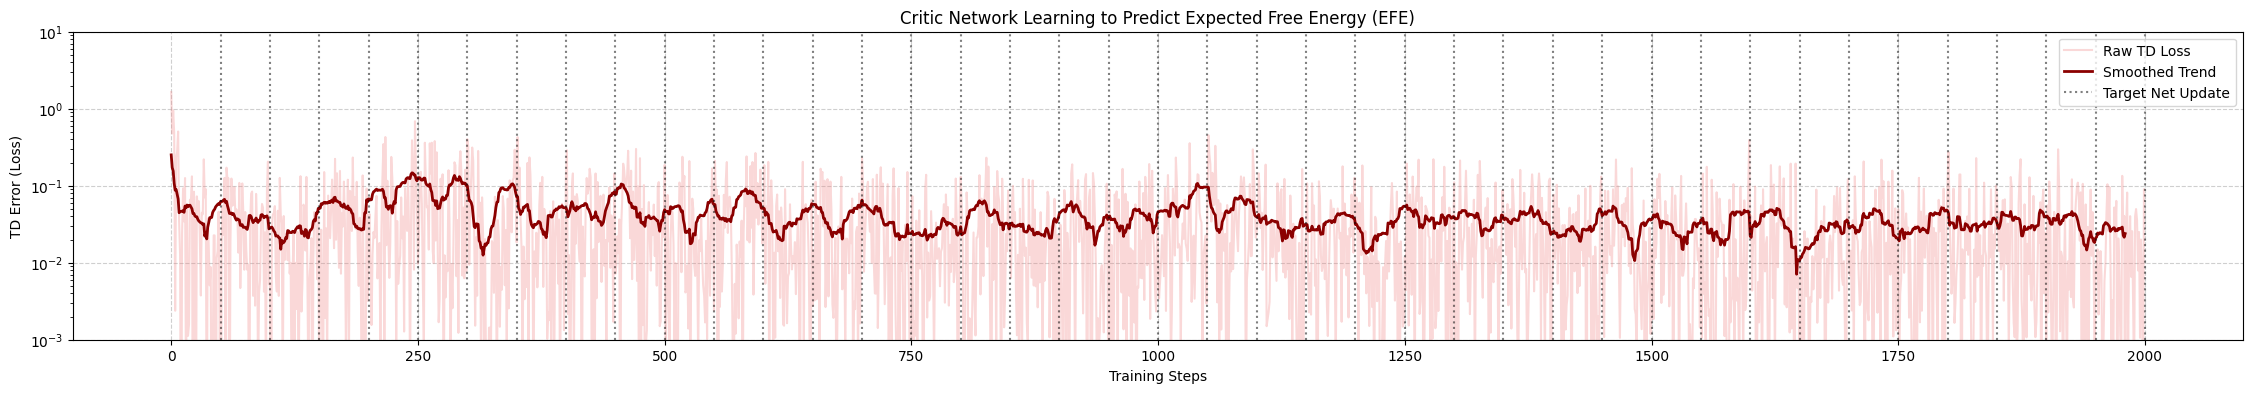


Training Complete! Notice the 'spikes' in the loss whenever the Target Network updates (dotted lines).
This proves the agent is actively adjusting its predictions of the future!


In [65]:
import copy

# 1. Re-initialize the Critic and its Target
critic_net = CriticNet(state_dim=2, num_actions=5).to(device)
target_critic_net = copy.deepcopy(critic_net)
target_critic_net.eval() # We never train the target network directly!
policy_net.eval() # keeping it simple right now, we wont train the policy, only the critic, but we could.
critic_optimizer = optim.Adam(critic_net.parameters(), lr=0.01)

# 2. Reset the environment and get Goal Coordinates
env.reset()
obs, true_s = env.reset()
goal_tensor = torch.FloatTensor(env.goal_location).unsqueeze(0).to(device) # o^* = (9, 9)

gamma = 0.9  # Discount factor (how much we care about the distant future)
critic_losses =[]

print("Starting Random Exploration Training for the Critic Net...\n")

# 3. The TD Training Loop (5000 steps of random wandering)
for step in range(1, 2001):
    
    # A. Format Current State
    s_t_tensor = torch.FloatTensor(true_s).unsqueeze(0).to(device)
    
    # B. Take an action in the environment using our policy net
    action = policy_net(s_t_tensor).argmax().item()
    next_obs, next_true_s = env.step(action)
    
    # C. Prepare tensors for the next step
    next_obs_tensor = torch.FloatTensor(next_obs).unsqueeze(0).to(device)
    next_true_s_tensor = torch.FloatTensor(next_true_s).unsqueeze(0).to(device)
    action_one_hot = F.one_hot(torch.tensor([action]), num_classes=env.action_space_size).float().to(device)
    
    # D. Ask our PREVIOUSLY TRAINED Posterior Net to guess the next state!
    with torch.no_grad():
        next_s_hat = posterior_net(next_obs_tensor, action_one_hot)
        
    # E. Calculate the 1-Step EFE Feedback
    # Epistemic Gain: -0.5 * || s_next - \hat{s}_next ||^2  (Minus because we WANT this to lower EFE)
    epistemic_gain = -0.5 * F.mse_loss(next_true_s_tensor, next_s_hat)
    
    # Pragmatic Penalty: +0.5 * || o_next - o^* ||^2       (Plus because distance from goal INCREASES EFE)
    pragmatic_penalty = 0.5 * F.mse_loss(next_obs_tensor, goal_tensor)
    
    one_step_efe = epistemic_gain + pragmatic_penalty
    
    # F. Compute the Future Expected Free Energy (Bootstrapping)
    with torch.no_grad():
        future_efe_estimates = target_critic_net(next_true_s_tensor)
        min_future_efe = torch.min(future_efe_estimates) # Min because EFE is a cost!
        
    target_efe = one_step_efe + (gamma * min_future_efe)
    
    # G. What did our Critic predict for the action we took?
    current_efe_estimates = critic_net(s_t_tensor)
    predicted_efe = current_efe_estimates[0, action] 
    
    # H. Calculate Loss & Backpropagate
    loss = F.mse_loss(predicted_efe, target_efe)
    
    critic_optimizer.zero_grad()
    loss.backward()
    critic_optimizer.step()
    
    critic_losses.append(loss.item())
    
    # I. UPDATE THE TARGET NETWORK (Every 100 steps)
    if step % 100 == 0:
        target_critic_net.load_state_dict(critic_net.state_dict())
        
    # Move to the next state
    true_s = next_true_s
    obs = next_obs
    
    if step % 100 == 0:
        print(f"Step {step:<4} | 1-Step EFE: {one_step_efe.item():.2f} | Predicted EFE: {predicted_efe.item():.2f} | Target EFE: {target_efe.item():.2f} | Loss: {loss.item():.2f}")

# 4. Plot the TD Learning Convergence
smoothed_critic_losses = moving_average(critic_losses, window_size=20)

plt.figure(figsize=(28, 4))
plt.plot(critic_losses, alpha=0.3, color='lightcoral', label='Raw TD Loss')
plt.plot(smoothed_critic_losses, color='darkred', linewidth=2, label='Smoothed Trend')

# Add vertical lines to show Target Network updates
for i in range(50, 2001, 50):
    if i == 100:
        plt.axvline(x=i, color='black', linestyle=':', alpha=0.5, label='Target Net Update')
    else:
        plt.axvline(x=i, color='black', linestyle=':', alpha=0.5)

plt.title("Critic Network Learning to Predict Expected Free Energy (EFE)")
plt.xlabel("Training Steps")
plt.ylabel("TD Error (Loss)")
plt.yscale('log')
plt.ylim([10e-4,10])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nTraining Complete! Notice the 'spikes' in the loss whenever the Target Network updates (dotted lines).")
print("This proves the agent is actively adjusting its predictions of the future!")

### Summary of implementation:

We are finally ready to write our Deep Active Inference training loop! First, we initialize our neural networks:

$$
\begin{aligned}
&\text{1. Posterior Net:} \quad &&\mathbf{q}_{\theta}\leftarrow \theta_{init}\\
&\text{2. Policy Net:} \quad &&\mathbf{Q}_{\phi} \leftarrow \phi_{init} \quad &&\text{(Outputs a probability distribution over actions)}\\
&\text{3. Critic Net:} \quad &&\mathbf{G}_{\psi} \leftarrow \psi_{init} \quad &&\text{(Outputs estimated EFE for all actions)}\\
&\text{4. Target Critic:} \quad &&\hat{\mathbf{G}}_{\hat{\psi}} \leftarrow  \mathbf{G}_{\psi} \quad &&\text{(For training stability)}\\
\end{aligned}
$$

Then:

- Choose your favorite value for  $a_{-1}$

- For each $t \in \{0,..., T\}$ do:


  **1. Perceive & Act:**
  - Observe $o_t$ from the environment.
  - Infer the current state $\hat{s}_{t}$ using the posterior net:
  $$\hat{s}_{t} = \mathbf{q}_{\theta}(o_{t},\, a_{t-1})$$


- Choose a new action $a_t$ by sampling from the policy net's distribution:
  $$
  \begin{aligned}
  \pi_t &= \mathbf{Q}_{\phi}(\hat{s}_{t}) \\
  a_t &\sim \pi_t
  \end{aligned}
  $$
- Execute action $a_t$ in the environment.


  **2. Unhide & Learn (Retrospective Update):**
  - If the environment allows, observe the unhidden true state $s_{t-1}$. 

- If $t \ge 2$, we have enough history to evaluate the transition $t-2 \to t-1$. We optimise our networks using standard Gradient Descent (with learning rate $\epsilon$):

  $$
  \begin{aligned}
  &\text{A) Posterior (VFE complexity minimisation):}\\
  &\tilde{s}_{t-1} =  \mathbf{q}_{\theta}(o_{t-1}, a_{t-2})\\
  &\theta \leftarrow \theta - \epsilon \nabla_\theta \left(\frac{1}{2} ||\tilde{s}_{t-1} - s_{t-1} ||^2_2\right)\\
  \\
  &\text{B) Policy (Match the EFE Gibbs distribution):}\\
  &\pi_{t-1} = \mathbf{Q}_{\phi}({s}_{t-1})\\
  &\phi \leftarrow \phi - \epsilon \nabla_\phi \left( ||\pi_{t-1} - \sigma[-\zeta \mathbf{G}_{\psi}(\mathbf{a}, s_{t-1})]||^2_2\right)\\
  \\
  &\text{C) Critic (EFE minimisation via Temporal Difference):}\\
  &\mathcal{G}_{target} = - \underbrace{\frac{1}{2} \left\| s_{t-1} - \hat{s}_{t-1} \right\|_2^2}_{\text{Epistemic}} + \underbrace{\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2}_{\text{Pragmatic}} + \gamma \, \min_a \left[ \hat{\mathbf{G}}_{\hat{\psi}}(a, s_{t-1}) \right]\\
  &\psi \leftarrow \psi - \epsilon \nabla_\psi \left( ||\mathbf{G}_{\psi}(a_{t-2}, s_{t-2}) - \mathcal{G}_{target}||^2_2\right)\\
  \end{aligned}
  $$

  **3. Target Network Update:**
  - Adjust your critic's target every $M$ steps:
  $$
  \begin{aligned}
  \hat{\mathbf{G}}_{\hat{\psi}} \leftarrow  \mathbf{G}_{\psi}
  \end{aligned}
  $$


*(Note 1: $\mathbf{G}_{\psi}(\mathbf{a}, s_{t-1})$ outputs a vector of EFE values for all possible actions. The notation $\mathbf{G}_{\psi}(a_{t-2}, s_{t-2})$ means we compute the vector for state $s_{t-2}$ and index the specific scalar component corresponding to the action $a_{t-2}$ that we actually took.)*

*(Note 2: Because EFE is a cost that we want to **minimise**, our future Critic target uses a $\min$ operator, akin to Q-learning. If you prefer on-policy SARSA, you could replace $\min_a [\dots]$ with the EFE of the specific action $a_{t-1}$ we took).*

*(Note 3: Yes, this tutorial uses discrete action spaces! That's why we map our Critic values into a probability simplex using a Softmax $\sigma$. Give me some time, I'll make some stuff for continuous action spaces soon...)*

# Implementing a DAI agent in pytorch

## The agent:

In [24]:
class ActiveInferenceAgent:
    """
    The Active Inference agent. It uses a posterior network to infer its state,
    a policy network to choose actions, and a critic network to evaluate EFE.
    """
    def __init__(self, state_size=2, action_size=5, lr=1e-3, gamma=0.9, zeta=2.0):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.zeta = zeta
        self.memory = deque(maxlen=10000)

        # Initialize the 3 Brains
        self.posterior_net = PosteriorNet(obs_dim=state_size, action_dim=action_size, state_dim=state_size).to(device)
        self.policy_net = PolicyNet(state_dim=state_size, num_actions=action_size).to(device)
        self.critic_net = CriticNet(state_dim=state_size, num_actions=action_size).to(device)

        # Target Critic for stable TD learning
        self.target_critic_net = CriticNet(state_dim=state_size, num_actions=action_size).to(device)
        self.update_target_critic()
        self.target_critic_net.eval()

        # Optimizers
        self.posterior_optimizer = optim.Adam(self.posterior_net.parameters(), lr=lr)
        self.policy_optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr)

    def infer_state(self, observation, last_action):
        """Infers the current hidden state."""
        obs_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)
        # One-hot encode the discrete action so the neural network can read it
        action_tensor = F.one_hot(torch.tensor([last_action]), num_classes=self.action_size).float().to(device)
        
        with torch.no_grad():
            inferred_state = self.posterior_net(obs_tensor, action_tensor)
        return inferred_state.squeeze(0).cpu().numpy()

    def choose_action(self, inferred_state):
        """Selects an action using the Policy Network."""
        state_tensor = torch.FloatTensor(inferred_state).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = self.policy_net(state_tensor)
            action_probs = F.softmax(logits, dim=-1)
            
        action = torch.multinomial(action_probs, 1).item()
        return action

    def update_target_critic(self):
        """Copies weights to the target critic."""
        self.target_critic_net.load_state_dict(self.critic_net.state_dict())

    def remember(self, true_s_t, a_t_minus_1, a_t, true_s_t_plus_1, obs_t, obs_t_plus_1, goal):
        """Stores a transition in the replay buffer."""
        self.memory.append((true_s_t, a_t_minus_1, a_t, true_s_t_plus_1, obs_t, obs_t_plus_1, goal))

    def replay(self, batch_size):
        """Trains all 3 networks using a batch of experiences."""
        if len(self.memory) < batch_size:
            return None, None, None

        minibatch = random.sample(self.memory, batch_size)
        true_s_ts, a_t_minus_1s, a_ts, true_s_t_plus_1s, obs_ts, obs_t_plus_1s, goals = zip(*minibatch)

        # Convert to tensors
        true_s_t = torch.FloatTensor(np.array(true_s_ts)).to(device)
        a_t_minus_1 = torch.LongTensor(np.array(a_t_minus_1s)).to(device)
        a_t = torch.LongTensor(np.array(a_ts)).to(device)
        true_s_t_plus_1 = torch.FloatTensor(np.array(true_s_t_plus_1s)).to(device)
        obs_t = torch.FloatTensor(np.array(obs_ts)).to(device)
        obs_t_plus_1 = torch.FloatTensor(np.array(obs_t_plus_1s)).to(device)
        goal_tensor = torch.FloatTensor(np.array(goals)).to(device)

        # One-hot encode the actions
        a_t_minus_1_oh = F.one_hot(a_t_minus_1, num_classes=self.action_size).float()
        a_t_oh = F.one_hot(a_t, num_classes=self.action_size).float()

        # =======================================================
        # A) Update Posterior Net (Minimize VFE Complexity)
        # =======================================================
        inferred_s_t = self.posterior_net(obs_t, a_t_minus_1_oh)
        
        # 0.5 * || \hat{s}_t - s_t ||^2
        posterior_loss = 0.5 * F.mse_loss(inferred_s_t, true_s_t)

        self.posterior_optimizer.zero_grad()
        posterior_loss.backward()
        self.posterior_optimizer.step()

        # =======================================================
        # B) Update Policy Net (Match the Gibbs Distribution)
        # =======================================================
        # Target: \sigma[-\zeta * G(s_t)]
        with torch.no_grad():
            efe_estimates = self.critic_net(inferred_s_t.detach()) 
            target_action_probs = F.softmax(-self.zeta * efe_estimates, dim=-1)

        # Current Policy predictions
        policy_logits = self.policy_net(inferred_s_t.detach())
        current_action_probs = F.softmax(policy_logits, dim=-1)

        # Minimize difference between Policy and Gibbs distribution
        policy_loss = F.mse_loss(current_action_probs, target_action_probs)

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()

        # =======================================================
        # C) Update Critic Net (Minimize EFE Prediction Error)
        # =======================================================
        with torch.no_grad():
            inferred_s_t_plus_1 = self.posterior_net(obs_t_plus_1, a_t_oh)

            # Epistemic Gain (Curiosity: Negative distance. Encourages exploration)
            epistemic_gain = -0.5 * torch.sum((true_s_t_plus_1 - inferred_s_t_plus_1)**2, dim=1)
            
            # Pragmatic Penalty (Goal-seeking: Positive distance. Penalizes being far from goal)
            pragmatic_penalty = 0.5 * torch.sum((obs_t_plus_1 - goal_tensor)**2, dim=1)

            one_step_efe = epistemic_gain + pragmatic_penalty

            # EFE is a cost! So we want the MINIMUM future EFE
            next_efe_values = self.target_critic_net(inferred_s_t_plus_1)
            min_next_efe, _ = torch.min(next_efe_values, dim=1)

            target_efe = one_step_efe + self.gamma * min_next_efe

        # What did the critic predict for the action we ACTUALLY took?
        predicted_efe_values = self.critic_net(inferred_s_t.detach())
        predicted_efe = predicted_efe_values.gather(1, a_t.unsqueeze(1)).squeeze()

        critic_loss = F.mse_loss(predicted_efe, target_efe)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        return posterior_loss.item(), policy_loss.item(), critic_loss.item()

## Why do we need a Replay Buffer?

Up to now we have trained:

- Posterior net → using real (unhidden) states right after each step  
- Policy net → supervised to match a hand-crafted proxy Gibbs distribution  
- Critic net → using temporal-difference targets computed on-the-fly during random exploration

But when we train **all three networks together**, several things become more challenging:

1. The agent's own policy is now **on-policy** (not random anymore) → the states we visit become **correlated** and **non-stationary**
2. We want to **reuse past experiences** many times (especially valuable goal-reaching or hint-taking transitions)
3. We want to **break temporal correlations** so that gradients are more stable
4. We want to learn **off-policy** from a mixture of past behaviors (exploration + emerging goal-directed behavior)

This is exactly why almost every modern deep RL / deep active inference agent uses a **Replay Buffer** (also called Experience Replay or Memory Buffer).

### What is a Replay Buffer?

It is simply a **fixed-size queue** (usually implemented with `collections.deque`) that stores transitions of the form:

**(s_t, a_{t-1}, a_t, s_{t+1}, o_t, o_{t+1}, goal)**

(or any variant that contains the information needed to compute all three losses)

Every time the agent interacts with the environment, we **append** a new transition.

When we want to train, we **randomly sample a mini-batch** from this buffer (usually 32–256 transitions).

Because samples are drawn **uniformly at random** (or sometimes prioritized), we:

- Reduce correlation between consecutive samples  
- Reuse rare but informative experiences (e.g. reaching the goal, using Hint successfully)  
- Stabilize training even when the policy is changing rapidly

### In this tutorial we use:

- `deque(maxlen=10000)` → oldest experiences are automatically forgotten when full  
- We store **true states** (s_t, s_{t+1}) because in our simple gridworld the environment "unhides" them for training  
- We also store both **observations** and **goal location** so we can compute pragmatic value and replay training

In more realistic settings we would **not** have access to true states — we would only store observations and actions, and rely entirely on the posterior network to reconstruct beliefs.

Now let's see it in action inside the `ActiveInferenceAgent` class — look at these methods:

- `remember(...)` → appends one transition  
- `replay(batch_size)` → samples random batch + computes **all three losses** at once

We are now ready to train everything **jointly** using experience replay.

🚀 Starting joint Active Inference training from scratch...

Episode   1 | Steps: 150 | P-loss: 2.5309 | Pol-loss: 0.0025 | C-loss: 1133.5735 | Final dist to goal: 8.00 ❌
Episode   2 | Steps:  31 | P-loss: 0.0952 | Pol-loss: 0.0451 | C-loss: 840.1978 | Final dist to goal: 0.00 ✅
Episode   3 | Steps: 150 | P-loss: 0.0527 | Pol-loss: 0.0181 | C-loss: 586.2810 | Final dist to goal: 3.00 ❌
Episode   4 | Steps: 150 | P-loss: 0.0862 | Pol-loss: 0.0016 | C-loss: 261.3133 | Final dist to goal: 3.00 ❌
Episode   5 | Steps:   3 | P-loss: 0.1036 | Pol-loss: 0.0005 | C-loss: 203.1078 | Final dist to goal: 0.00 ✅
Episode   6 | Steps: 150 | P-loss: 0.1163 | Pol-loss: 0.0179 | C-loss: 253.3435 | Final dist to goal: 9.00 ❌
Episode   7 | Steps: 150 | P-loss: 0.1131 | Pol-loss: 0.0892 | C-loss: 219.9882 | Final dist to goal: 4.00 ❌
Episode   8 | Steps:   1 | P-loss: 0.1267 | Pol-loss: 0.0051 | C-loss: 305.7748 | Final dist to goal: 0.00 ✅
Episode   9 | Steps: 150 | P-loss: 0.1223 | Pol-loss: 0.0017 | C-lo

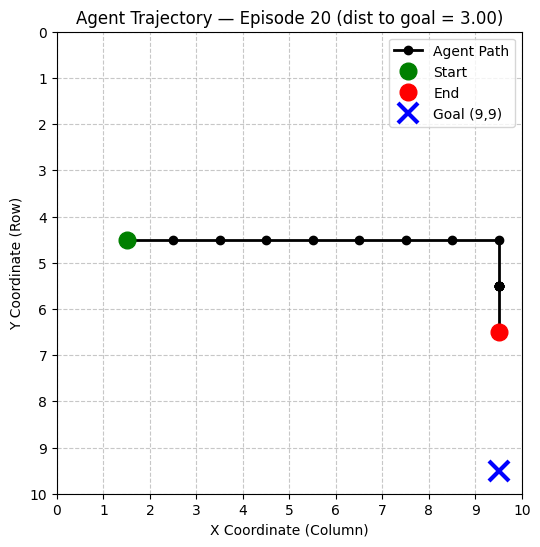

Episode  21 | Steps:   4 | P-loss: 0.1674 | Pol-loss: 0.0006 | C-loss: 124.1099 | Final dist to goal: 0.00 ✅
Episode  22 | Steps: 150 | P-loss: 0.1503 | Pol-loss: 0.0004 | C-loss: 137.3313 | Final dist to goal: 2.00 ❌
Episode  23 | Steps: 150 | P-loss: 0.1479 | Pol-loss: 0.0004 | C-loss: 124.5232 | Final dist to goal: 2.00 ❌
Episode  24 | Steps: 150 | P-loss: 0.1497 | Pol-loss: 0.0008 | C-loss: 126.9867 | Final dist to goal: 3.00 ❌
Episode  25 | Steps: 150 | P-loss: 0.1451 | Pol-loss: 0.0004 | C-loss: 113.7330 | Final dist to goal: 2.00 ❌
Episode  26 | Steps: 150 | P-loss: 0.1431 | Pol-loss: 0.0008 | C-loss: 110.3010 | Final dist to goal: 1.00 ❌
Episode  27 | Steps: 150 | P-loss: 0.1439 | Pol-loss: 0.0006 | C-loss: 98.8713 | Final dist to goal: 2.00 ❌
Episode  28 | Steps: 150 | P-loss: 0.1415 | Pol-loss: 0.0004 | C-loss: 96.7626 | Final dist to goal: 2.00 ❌
Episode  29 | Steps:   9 | P-loss: 0.1369 | Pol-loss: 0.0003 | C-loss: 124.2521 | Final dist to goal: 0.00 ✅
Episode  30 | Steps: 

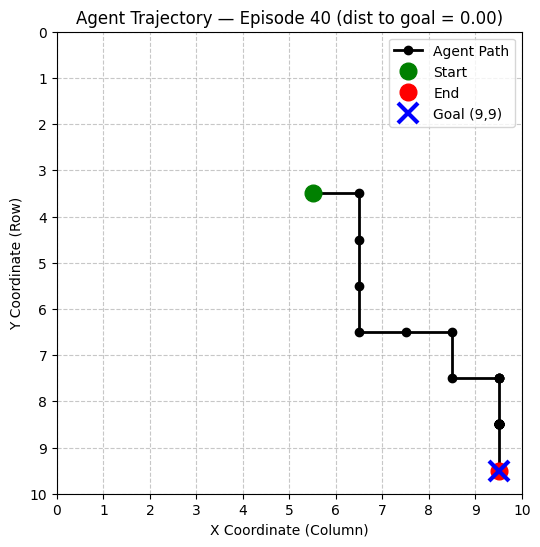

Episode  41 | Steps:  24 | P-loss: 0.1537 | Pol-loss: 0.0007 | C-loss: 101.4784 | Final dist to goal: 0.00 ✅
Episode  42 | Steps:  45 | P-loss: 0.1542 | Pol-loss: 0.0012 | C-loss: 90.0167 | Final dist to goal: 0.00 ✅
Episode  43 | Steps:  31 | P-loss: 0.1555 | Pol-loss: 0.0016 | C-loss: 90.7893 | Final dist to goal: 0.00 ✅
Episode  44 | Steps:  11 | P-loss: 0.1465 | Pol-loss: 0.0018 | C-loss: 86.6351 | Final dist to goal: 0.00 ✅
Episode  45 | Steps:   1 | P-loss: 0.1236 | Pol-loss: 0.0023 | C-loss: 70.9374 | Final dist to goal: 0.00 ✅
Episode  46 | Steps:  13 | P-loss: 0.1484 | Pol-loss: 0.0007 | C-loss: 84.5685 | Final dist to goal: 0.00 ✅
Episode  47 | Steps:  25 | P-loss: 0.1534 | Pol-loss: 0.0012 | C-loss: 86.1212 | Final dist to goal: 0.00 ✅
Episode  48 | Steps:  40 | P-loss: 0.1635 | Pol-loss: 0.0012 | C-loss: 93.1458 | Final dist to goal: 0.00 ✅
Episode  49 | Steps:  51 | P-loss: 0.1587 | Pol-loss: 0.0015 | C-loss: 105.1269 | Final dist to goal: 0.00 ✅
Episode  50 | Steps:  12 |

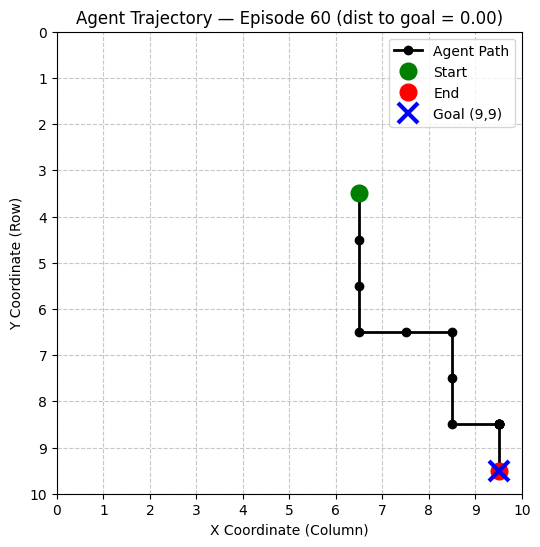

Episode  61 | Steps:  31 | P-loss: 0.1633 | Pol-loss: 0.0021 | C-loss: 111.3225 | Final dist to goal: 0.00 ✅
Episode  62 | Steps:  24 | P-loss: 0.1573 | Pol-loss: 0.0015 | C-loss: 83.8437 | Final dist to goal: 0.00 ✅
Episode  63 | Steps:  19 | P-loss: 0.1632 | Pol-loss: 0.0022 | C-loss: 87.9201 | Final dist to goal: 0.00 ✅
Episode  64 | Steps:   7 | P-loss: 0.1581 | Pol-loss: 0.0030 | C-loss: 96.7510 | Final dist to goal: 0.00 ✅
Episode  65 | Steps:   7 | P-loss: 0.1566 | Pol-loss: 0.0025 | C-loss: 82.2737 | Final dist to goal: 0.00 ✅
Episode  66 | Steps:  26 | P-loss: 0.1661 | Pol-loss: 0.0011 | C-loss: 76.0370 | Final dist to goal: 0.00 ✅
Episode  67 | Steps:  12 | P-loss: 0.1660 | Pol-loss: 0.0031 | C-loss: 94.3029 | Final dist to goal: 0.00 ✅
Episode  68 | Steps:  10 | P-loss: 0.1691 | Pol-loss: 0.0038 | C-loss: 93.8239 | Final dist to goal: 0.00 ✅
Episode  69 | Steps:   8 | P-loss: 0.1555 | Pol-loss: 0.0055 | C-loss: 92.3246 | Final dist to goal: 0.00 ✅
Episode  70 | Steps:  21 | 

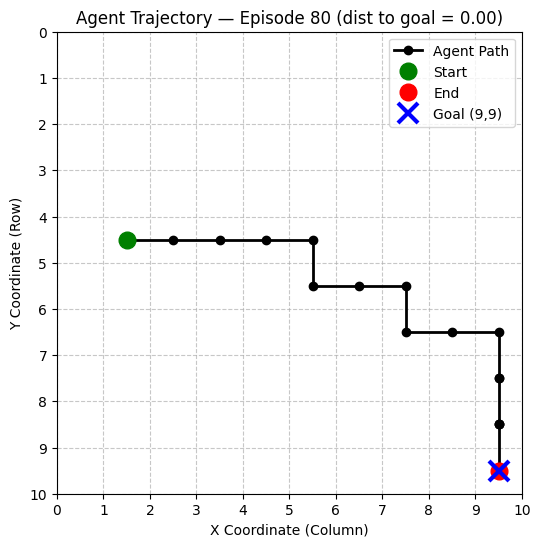

Episode  81 | Steps:  17 | P-loss: 0.1565 | Pol-loss: 0.0095 | C-loss: 68.7118 | Final dist to goal: 0.00 ✅
Episode  82 | Steps:   2 | P-loss: 0.1092 | Pol-loss: 0.0048 | C-loss: 94.3143 | Final dist to goal: 0.00 ✅
Episode  83 | Steps:  15 | P-loss: 0.1580 | Pol-loss: 0.0137 | C-loss: 90.2600 | Final dist to goal: 0.00 ✅
Episode  84 | Steps:  12 | P-loss: 0.1619 | Pol-loss: 0.0122 | C-loss: 100.9959 | Final dist to goal: 0.00 ✅
Episode  85 | Steps:  19 | P-loss: 0.1563 | Pol-loss: 0.0089 | C-loss: 100.1023 | Final dist to goal: 0.00 ✅
Episode  86 | Steps:   9 | P-loss: 0.1618 | Pol-loss: 0.0134 | C-loss: 86.6740 | Final dist to goal: 0.00 ✅
Episode  87 | Steps:   6 | P-loss: 0.1622 | Pol-loss: 0.0076 | C-loss: 86.3134 | Final dist to goal: 0.00 ✅
Episode  88 | Steps:  10 | P-loss: 0.1649 | Pol-loss: 0.0119 | C-loss: 122.0592 | Final dist to goal: 0.00 ✅
Episode  89 | Steps:  12 | P-loss: 0.1771 | Pol-loss: 0.0091 | C-loss: 95.3874 | Final dist to goal: 0.00 ✅
Episode  90 | Steps:  15 

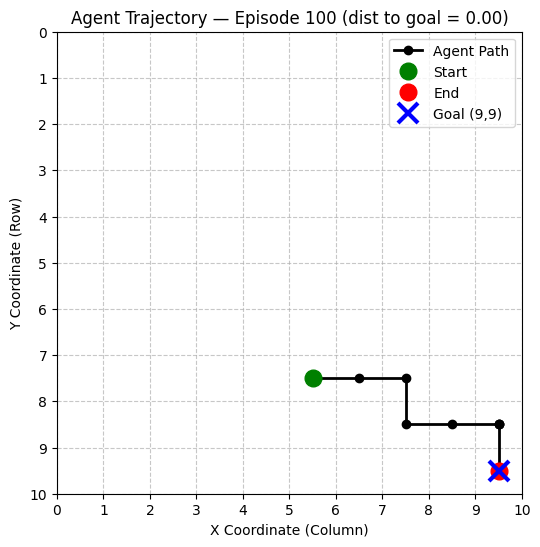


FINAL TEST EPISODE (pure policy evaluation)


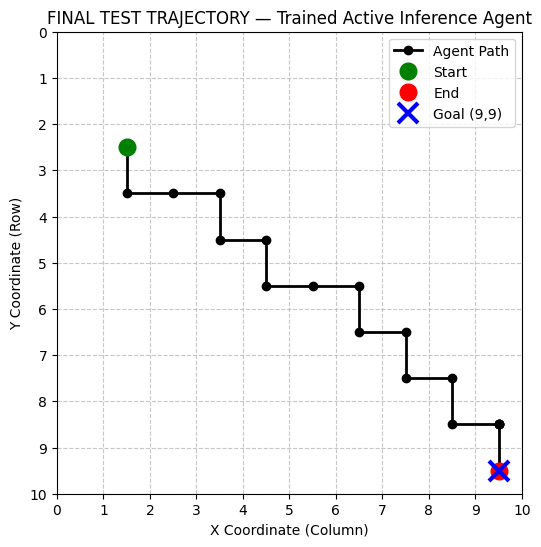

Test finished! Final distance to goal: 0.00 🎉 REACHED GOAL!


In [70]:
# =============================================================================
# FULL JOINT TRAINING OF THE ACTIVE INFERENCE AGENT (from scratch)
# =============================================================================
# This cell trains ALL three networks together exactly as described in the
# "Summary of implementation" section of the tutorial.
# 
# • Posterior  ← minimises VFE Complexity (state inference)
# • Policy     ← matches the Gibbs distribution of the Critic (EFE)
# • Critic     ← learns the one-step + bootstrapped EFE via TD
# 
# We also show progressive reporting + live map visualisation every 50 episodes.

import random
import numpy as np

# ----------------------------------------------------------------------
# Create fresh agent and environment (true "from scratch")
# ----------------------------------------------------------------------
agent = ActiveInferenceAgent(state_size=2, action_size=5, lr=1e-3, gamma=0.9, zeta=2.0)
env   = GridWorld(size=10)

# Hyper-parameters
NUM_EPISODES        = 100
MAX_STEPS_PER_EP    = 150
BATCH_SIZE          = 64
TARGET_UPDATE_FREQ  = 200   # global steps
total_steps         = 0

print("🚀 Starting joint Active Inference training from scratch...\n")

for episode in range(1, NUM_EPISODES + 1):
    obs, true_s = env.reset()
    last_action = np.random.randint(0, env.action_space_size)  # random initial "phantom" action
    
    trajectory = [true_s.copy()]          # for visualisation
    p_losses   = []
    pol_losses = []
    c_losses   = []
    
    for step in range(MAX_STEPS_PER_EP):
        # 1. Perceive
        inferred_state = agent.infer_state(obs, last_action)
        
        # 2. Act (policy sampling)
        action = agent.choose_action(inferred_state)
        
        # 3. Environment step
        next_obs, next_true_s = env.step(action)
        trajectory.append(next_true_s.copy())
        
        # 4. Store experience (true states are "unhidden" for training)
        agent.remember(true_s, last_action, action, next_true_s,
                       obs, next_obs, env.goal_location)
        
        # 5. Train (if we have enough data)
        if len(agent.memory) >= BATCH_SIZE:
            p_loss, pol_loss, c_loss = agent.replay(BATCH_SIZE)
            if p_loss is not None:
                p_losses.append(p_loss)
                pol_losses.append(pol_loss)
                c_losses.append(c_loss)
        
        # 6. Periodic target network update (bootstrapping stability)
        total_steps += 1
        if total_steps % TARGET_UPDATE_FREQ == 0:
            agent.update_target_critic()
        
        # 7. Next iteration
        obs        = next_obs
        true_s     = next_true_s
        last_action = action
        
        # Early stop if we reached the goal (optional but nice)
        if np.linalg.norm(true_s - env.goal_location) < 0.8:
            break
    
    # ====================== PROGRESSIVE REPORTING ======================
    avg_p   = np.mean(p_losses)   if p_losses   else 0.0
    avg_pol = np.mean(pol_losses) if pol_losses else 0.0
    avg_c   = np.mean(c_losses)   if c_losses   else 0.0
    final_dist = np.linalg.norm(true_s - env.goal_location)
    
    print(f"Episode {episode:3d} | "
          f"Steps: {len(trajectory)-1:3d} | "
          f"P-loss: {avg_p:6.4f} | "
          f"Pol-loss: {avg_pol:6.4f} | "
          f"C-loss: {avg_c:6.4f} | "
          f"Final dist to goal: {final_dist:.2f} {'✅' if final_dist < 1.0 else '❌'}")
    
    # Live map visualisation every 50 episodes
    if episode % 20 == 0 or episode == NUM_EPISODES:
        plot_trajectory(trajectory,
                        grid_size=env.size,
                        goal_location=env.goal_location,
                        title=f'Agent Trajectory — Episode {episode} '
                              f'(dist to goal = {final_dist:.2f})')

# =============================================================================
# FINAL TEST RUN (no training, pure policy)
# =============================================================================
print("\n" + "="*60)
print("FINAL TEST EPISODE (pure policy evaluation)")
print("="*60)

obs, true_s = env.reset()
trajectory_test = [true_s.copy()]
last_action = 0

for _ in range(200):
    inferred = agent.infer_state(obs, last_action)
    action   = agent.choose_action(inferred)
    next_obs, next_true = env.step(action)
    
    trajectory_test.append(next_true.copy())
    obs = next_obs
    true_s = next_true
    last_action = action
    
    if np.linalg.norm(true_s - env.goal_location) < 0.5:
        break

plot_trajectory(trajectory_test,
                grid_size=env.size,
                goal_location=env.goal_location,
                title='FINAL TEST TRAJECTORY — Trained Active Inference Agent')

dist = np.linalg.norm(true_s - env.goal_location)
print(f"Test finished! Final distance to goal: {dist:.2f} "
      f"{'🎉 REACHED GOAL!' if dist < 1.0 else 'Still improving...'}")

![](figs/actinfclosing)